# **Delhivery**
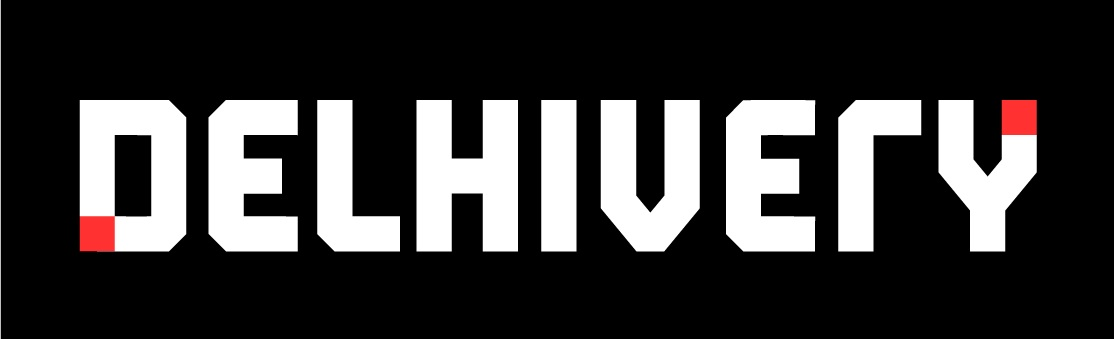

*Delhivery is the largest and fastest-growing fully integrated player in India by revenue in Fiscal 2021. They aim to build the operating system for commerce, through a combination of world-class infrastructure, logistics operations of the highest quality, and cutting-edge engineering and technology capabilities.*

*The Data team builds intelligence and capabilities using this data that helps them to widen the gap between the quality, efficiency, and profitability of their business versus their competitors.*

# **Problem Statement & Analyzing Basic Metrics:**

*Delhivery aims to establish itself as the premier player in the logistics industry. This case study is of paramount importance as it aligns with the company's core objectives and operational excellence. It provides a practical framework for understanding and processing data, which is
integral to their operations. By leveraging data engineering pipelines and data analysis techniques, Delhivery can achieve several critical goals. First, it allows them to ensure data integrity and quality by addressing missing values
and structuring the dataset appropriately. Second, it enables the extraction of valuable features from raw data, which can be utilized for building accurate forecasting models. Moreover, it facilitates the identification of patterns, insights, and actionable recommendations crucial for optimizing their logistics operations. By conducting hypothesis testing and outlier detection, Delhivery can refine their processes and further enhance the quality of service they provide.*

*We will gain hands-on experience in data preprocessing and cleaning, which is
often the most time-consuming aspect of data analysis. Feature engineering is a critical step in building machine learning models. In this case study, learners will understand how to extract meaningful features from raw data, including datetime manipulation and column splitting. The case study introduces learners to the concept of grouping data based on specific keys and then aggregating it. This is a key aspect of data analysis, especially when dealing with time-series data or data with a hierarchical structure.Learners will perform hypothesis testing, to validate assumptions and draw insights from data. The case study goes beyond data analysis by focusing on deriving actionable insights for a business. Learners will understand how data analysis can drive informed decision-making and recommendations.*

#**Features Of The Dataset:**

- Column Profiling:

| Feature | Description |
|:--------|:------------|
|data| tells whether the data is testing or training data|
|trip_creation_time| Timestamp of trip creation|
|route_schedule_uuid| Unique ID for a particular route schedule|
|**route_type**| **Transportation type**|
|a. FTL–Full Truck Load| FTL shipments get to the destination sooner, as the truck is making no other pickups or drop-offs along the way|
|b. Carting | Handling system consisting of small vehicles (carts)|
|trip_uuid| Unique ID given to a particular trip (A trip may include different source and destination centers)|
|source_center| Source ID of trip origin |
|source_name| Source Name of trip origin |
|destination_center| Destination ID |
|destination_name| Destination Name |
|od_start_time| Trip start time |
|od_end_time| Trip end time |
|start_scan_to_end_scan | Time taken to deliver from source to destination |
|is_cutoff | Unknown field |
|cutoff_factor | Unknown field|
|cutoff_timestamp | Unknown field|
|actual_distance_to_destination | Distance in kms between source and destination warehouse|
|actual_time | Actual time taken to complete the delivery (Cumulative) |
|osrm_time | An open-source routing engine time calculator which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) and gives the time (Cumulative) |
|osrm_distance | An open-source routing engine which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) (Cumulative) |
|factor | Unknown field |
| segment_actual_time | This is a segment time. Time taken by the subset of the package delivery|
|segment_osrm_time | This is the OSRM segment time. Time taken by the subset of the package delivery|
| segment_osrm_distance | This is the OSRM distance. Distance covered by subset of the package delivery|
| segment_factor | Unknown field |

In [108]:
#Importing libraries-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, mannwhitneyu, ttest_ind, shapiro, levene, zscore
from statsmodels.graphics.gofplots import qqplot
from sklearn.preprocessing import StandardScaler, OneHotEncoder

**Importing the dataset**

In [109]:
import gdown
!gdown 1NvLh8i2fBayJ--_voRNtsO_KSqXh_6rs

Downloading...
From: https://drive.google.com/uc?id=1NvLh8i2fBayJ--_voRNtsO_KSqXh_6rs
To: /content/delhivery_data.csv
100% 55.6M/55.6M [00:00<00:00, 57.9MB/s]


In [110]:
data= pd.read_csv('delhivery_data.csv')
pd.options.display.max_columns=999
pd.options.display.max_rows=999
data.head(5)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


#1. **Getting Basic Info About The Dataset- EDA**

In [111]:
data= data.sort_values(['trip_uuid', 'od_start_time'])

*Sorting the Data in ascending order based on trip_uuid and od_start_time, so that we can get correct order of transport.*

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144867 entries, 124981 to 11573
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff        

*>**Insight:** The dataset consists of 12 columns containing object datatype, while 1 column contains integer datatype, 1 column contains bool datatype and 10 column contains float64 datatype*

**Shape Of Dataset**

In [113]:
data.shape

(144867, 24)

*>**Insight:** The dataset consists 24 columns and 144867 rows*

**Statistical Summary**

In [114]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
start_scan_to_end_scan,144867.0,961.262986,1037.012769,20.000000,161.000000,449.000000,1634.000000,7898.000000
cutoff_factor,144867.0,232.926567,344.755577,9.000000,22.000000,66.000000,286.000000,1927.000000
actual_distance_to_destination,144867.0,234.073372,344.990009,9.000045,23.355874,66.126571,286.708875,1927.447705
actual_time,144867.0,416.927527,598.103621,9.000000,51.000000,132.000000,513.000000,4532.000000
osrm_time,144867.0,213.868272,308.011085,6.000000,27.000000,64.000000,257.000000,1686.000000
osrm_distance,144867.0,284.771297,421.119294,9.008200,29.914700,78.525800,343.193250,2326.199100
factor,144867.0,2.120107,1.715421,0.144000,1.604264,1.857143,2.213483,77.387097
segment_actual_time,144867.0,36.196111,53.571158,-244.000000,20.000000,29.000000,40.000000,3051.000000
segment_osrm_time,144867.0,18.507548,14.775960,0.000000,11.000000,17.000000,22.000000,1611.000000
segment_osrm_distance,144867.0,22.829020,17.860660,0.000000,12.070100,23.513000,27.813250,2191.403700


*>**Insight:** This function calculates summary statistics, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum, for numerical columns within the DataFrame. These statistics aid in comprehending the central tendency, spread, and distribution of the data.*

In [115]:
data.describe(include= 'object').T

,count,unique,top,freq
data,144867,2,training,104858
trip_creation_time,144867,14817,2018-09-19 04:07:34.091798,101
route_schedule_uuid,144867,1504,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,1812
route_type,144867,2,FTL,99660
trip_uuid,144867,14817,trip-153733005409156789,101
source_center,144867,1508,IND000000ACB,23347
source_name,144574,1498,Gurgaon_Bilaspur_HB (Haryana),23347
destination_center,144867,1481,IND000000ACB,15192
destination_name,144606,1468,Gurgaon_Bilaspur_HB (Haryana),15192
od_start_time,144867,26369,2018-09-21 18:37:09.322207,81


*>**Insight:** This command retrieves information about categorical data within the DataFrame, including the count of observations, the number of unique categories, the most frequent category, and its frequency for each categorical column.*

**Duplicate Values**

In [116]:
data.duplicated().any()

np.False_

In [117]:
data.duplicated().sum()

np.int64(0)

*>**Insight:** There are no duplicate rows in dataset.*

**Unique Values**

In [118]:
data.nunique()

,0
data,2
trip_creation_time,14817
route_schedule_uuid,1504
route_type,2
trip_uuid,14817
source_center,1508
source_name,1498
destination_center,1481
destination_name,1468
od_start_time,26369


**Missing Values**

In [119]:
data.isna().sum()/data.shape[0] * 100

,0
data,0.000000
trip_creation_time,0.000000
route_schedule_uuid,0.000000
route_type,0.000000
trip_uuid,0.000000
source_center,0.000000
source_name,0.202254
destination_center,0.000000
destination_name,0.180165
od_start_time,0.000000


In [120]:
data.dropna(inplace= True)

*As NAN values are less than < 3%, we will drop them.*

In [121]:
data.isna().sum().sum()

np.int64(0)

In [122]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144316 entries, 124981 to 11573
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144316 non-null  object 
 1   trip_creation_time              144316 non-null  object 
 2   route_schedule_uuid             144316 non-null  object 
 3   route_type                      144316 non-null  object 
 4   trip_uuid                       144316 non-null  object 
 5   source_center                   144316 non-null  object 
 6   source_name                     144316 non-null  object 
 7   destination_center              144316 non-null  object 
 8   destination_name                144316 non-null  object 
 9   od_start_time                   144316 non-null  object 
 10  od_end_time                     144316 non-null  object 
 11  start_scan_to_end_scan          144316 non-null  float64
 12  is_cutoff        

*There are no missing values now.*

In [123]:
data.drop(['is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'factor', 'segment_factor'], axis= 1, inplace= True)

*Removing unwanted columns*

**Converting Columns To Category and Datetime**

In [124]:
dates= ['trip_creation_time', 'od_start_time', 'od_end_time']

for col in dates:
    data[col]= pd.to_datetime(data[col], errors= 'coerce')

cat= ['data', 'route_type']

for col in cat:
    data[col]= data[col].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144316 entries, 124981 to 11573
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144316 non-null  category      
 1   trip_creation_time              144316 non-null  datetime64[ns]
 2   route_schedule_uuid             144316 non-null  object        
 3   route_type                      144316 non-null  category      
 4   trip_uuid                       144316 non-null  object        
 5   source_center                   144316 non-null  object        
 6   source_name                     144316 non-null  object        
 7   destination_center              144316 non-null  object        
 8   destination_name                144316 non-null  object        
 9   od_start_time                   144316 non-null  datetime64[ns]
 10  od_end_time                     144316 non-null  datetime

*>**Insight:** The dataset consists of 3 columns containing datetime64[ns] datatype and 2 column contains category datatype*

# **2. Try merging the rows using the hint mentioned below.**

*Since delivery details of one package is divided into several rows (think of it as connecting flights to reach a particular destination).*

*Now think about…*

*● How should we treat their fields if we combine these rows?*

*● What aggregation would make sense if we merge?*

*● What would happen to the numeric fields if we merge the rows?*

*1. Grouping by segment*
*a. Create a unique identifier for different segments of a trip based on the
combination of the trip_uuid, source_center, and destination_center and
name it as segment_key.*

*b. You can use inbuilt functions like groupby and aggregations like
cumsum() to merge the rows in columns segment_actual_time,
segment_osrm_distance, segment_osrm_time based on the
segment_key.*

*c. This way you’ll get new columns named segment_actual_time_sum,
segment_osrm_distance_sum, segment_osrm_time_sum.*

*2. Aggregating at segment level*

*a. Create a dictionary named create_segment_dict, that defines how to
aggregate and select values.*

*i. You can keep the first and last values for some
numeric/categorical fields if aggregating them won’t make sense.*

*b. Further group the data by segment_key because you want to perform
aggregation operations for different segments of each trip based on the
segment_key value.*

*c. The aggregation functions specified in the create_segment_dict are
applied to each group of rows with the same segment_key.*

*d. Sort the resulting DataFrame segment, by two criteria:*

*i. First, it sorts by segment_key to ensure that segments are
ordered consistently.*

*ii. Second, it sorts by od_end_time in ascending order, ensuring that
segments within the same trip are ordered by their end times
from earliest to latest.*

**Understanding the logistics**

In [125]:
data[data['trip_uuid'] == 'trip-153741093647649320']

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,10.435660,14.0,11.0,11.9653,14.0,11.0,11.9653
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,18.936842,24.0,20.0,21.7243,10.0,9.0,9.7590
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,27.637279,40.0,28.0,32.5395,16.0,7.0,10.8152
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,36.118028,62.0,40.0,45.5620,21.0,12.0,13.0224
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,39.386040,68.0,44.0,54.2181,6.0,5.0,3.9153
5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,10.403038,15.0,11.0,12.1171,15.0,11.0,12.1171
6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,18.045481,44.0,17.0,21.2890,28.0,6.0,9.1719
7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,28.061896,65.0,29.0,35.8252,21.0,11.0,14.5362
8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,38.939167,76.0,39.0,47.1900,10.0,10.0,11.3648
9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,43.595802,102.0,45.0,53.2334,26.0,6.0,6.0434


*Created a segment key*

In [126]:
data['segment_key']= data['trip_uuid'] + data['source_center'] + data['destination_center']

*Created a segment_dict*

In [127]:
segment_dict= {
    'data' : 'first',
    'trip_creation_time': 'first',
    'route_schedule_uuid': 'first',
    'route_type': 'first',
    'trip_uuid': 'first',
    'source_center': 'first',
    'source_name': 'first',
    'destination_center': 'first',
    'destination_name': 'first',

    'od_start_time': 'first',
    'od_end_time': 'first',

    'start_scan_to_end_scan': 'first',

    'actual_time': 'last',
    'osrm_time': 'last',

    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',

    'actual_distance_to_destination': 'last',
    'osrm_distance': 'last',
    'segment_osrm_distance': 'sum'
}

*grouped by segment_key and agg on segment_dict*

In [128]:
data= data.groupby('segment_key').agg(segment_dict).reset_index()

*Checking 1 trip_uuid to understand data*

In [129]:
data[data['trip_uuid'] == 'trip-153741093647649320']

,segment_key,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_time,osrm_time,segment_actual_time,segment_osrm_time,actual_distance_to_destination,osrm_distance,segment_osrm_distance
10370,trip-153741093647649320IND388121AAAIND388620AAB,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,68.0,44.0,67.0,44.0,39.386040,54.2181,49.4772
10371,trip-153741093647649320IND388620AABIND388320AAA,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,102.0,45.0,100.0,44.0,43.595802,53.2334,53.2334


*We have 2 rows for 1 trip_uuid, we need to agg then to get single row now*

*Created a segment_dict2 to fuuther agg the data*

In [130]:
segment_dict2= {
    'data' : 'first',
    'trip_creation_time': 'first',
    'route_schedule_uuid': 'first',
    'route_type': 'first',
    'trip_uuid': 'first',

    'source_center': 'first',
    'source_name': 'first',

    'destination_center': 'last',
    'destination_name': 'last',

    'od_start_time': 'first',
    'od_end_time': 'last',

    'start_scan_to_end_scan': 'sum',

    'actual_time': 'sum',
    'osrm_time': 'sum',

    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',

    'actual_distance_to_destination': 'sum',
    'osrm_distance': 'sum',
    'segment_osrm_distance': 'sum'
}

*grouped by segment_key and agg on segment_dict2*

In [131]:
data= data.groupby('trip_uuid').agg(segment_dict2).reset_index(drop= True)

**After groupby, we can see that there is only 1 agg row per trip_uuid**

In [132]:
data[data['trip_uuid'] == 'trip-153741093647649320']

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_time,osrm_time,segment_actual_time,segment_osrm_time,actual_distance_to_destination,osrm_distance,segment_osrm_distance
5917,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 06:36:55.627764,195.0,170.0,89.0,167.0,88.0,82.981842,107.4515,102.7106


In [133]:
data.shape

(14787, 19)

**There is a significant reduction in row count from 144316 to 14787**

# **3. Feature Engineering**

**Calculate time taken between od_start_time and od_end_time and keep it as a
feature named od_time_diff_hour. Drop the original columns, if required**

In [134]:
data['od_time_diff_hour']= (data['od_end_time'] - data['od_start_time']).dt.total_seconds()/60
data['od_time_diff_hour']

,od_time_diff_hour
0,0.000000
1,0.000000
2,0.000000
3,100.494935
4,232.556228
...,...
14782,405.485842
14783,60.590521
14784,0.000000
14785,149.831354


**Destination Name: Split and extract features out of destination. City-place-code (State)**

**Source Name: Split and extract features out of destination. City-place-code (State)**

In [135]:
data['destination_name'] = data['destination_name'].str.lower() #lowering all columns
data['source_name'] = data['source_name'].str.lower()

In [136]:
def states(address):
    state= address.split('(')[1][:-1] ## transform  "gurgaon_bilaspur_hb (haryana)" into "gurgaon_bilaspur_hb" "(haryana)), #removing ')' from ending
    return state

def city(address):
    city= address.split('_')[0]

    #Now dealing with edge cases

    if city == 'pnq vadgaon sheri dpc':
      return 'vadgaonsheri'

    # ['PNQ Pashan DPC', 'Bhopal MP Nagar', 'HBR Layout PC',
    #  'PNQ Rahatani DPC', 'Pune Balaji Nagar', 'Mumbai Antop Hill']

    if city in ['pnq pashan dpc','pnq rahatani dpc', 'pune balaji nagar']:
        return 'pune'

    if city == 'hbr layout pc' : return 'bengaluru'
    if city == 'bhopal mp nagar' : return 'bhopal'
    if city == 'mumbai antop hill' : return 'mumbai'


    return city

def place(address):
    place= address.split(' (')[0] #remove state
    place_len= len(place.split('_')) #check len of place
    place_= place.split('_')

    if place_len >= 3: #get place
        return place_[1]

    if place_len == 2: #for small city we will keep city and place same
        return place_[0]

    # Now we need to deal with edge cases or imporper name convention
    return place.split(' ')[0]


def code(address):
    # We will remove state
    code = address.split(' (')[0]

    if len(code.split('_')) >= 3 : #get last val
        return code.split('_')[-1]

    return 'none'

In [137]:
data['destination_state']= data['destination_name'].apply(lambda x: states(x))
data['destination_city']= data['destination_name'].apply(lambda x: city(x))
data['destination_place']= data['destination_name'].apply(lambda x: place(x))
data['destination_code']= data['destination_name'].apply(lambda x: code(x))

In [138]:
data[['destination_state', 'destination_city', 'destination_place', 'destination_code']].sample(10)

,destination_state,destination_city,destination_place,destination_code
3165,karnataka,bangalore,nelmngla,h
10913,karnataka,bengaluru,bomsndra,hb
172,madhya pradesh,jabalpur,adhartal,ip
6433,rajasthan,sultana,central,1
2361,kerala,sultnbthry,kollgpra,d
3156,maharashtra,bhiwandi,mankoli,hb
10800,maharashtra,lowerparel,lowerparel,none
3549,west bengal,fatepur,nh117,d
14309,madhya pradesh,bhopal,trnsport,h
4602,tamil nadu,chennai,madhavaram,l


In [139]:
data['source_state']= data['source_name'].apply(lambda x: states(x))
data['source_city']= data['source_name'].apply(lambda x: city(x))
data['source_place']= data['source_name'].apply(lambda x: place(x))
data['source_code']= data['source_name'].apply(lambda x: code(x))

In [140]:
data[['source_state', 'source_city', 'source_place', 'source_code']].sample(10)

,source_state,source_city,source_place,source_code
6710,tamil nadu,chennai,chrompet,dpc
3551,karnataka,bengaluru,kgairprt,hb
14503,kerala,kozhikode,central,4
13693,karnataka,bengaluru,bnnrghta,l
10010,delhi,delhi,kapshera,l
11313,rajasthan,barisadri,bhmprdpp,d
2616,haryana,gurgaon,bilaspur,hb
12673,tamil nadu,coimbatore,karayam,h
10700,uttar pradesh,basti,gndhingr,d
7807,rajasthan,kishangarh,central,2


**Trip_creation_time: Extract features like month, year, day, etc.**

In [141]:
data['trip_year']= data['trip_creation_time'].dt.year
data['trip_day']= data['trip_creation_time'].dt.day_name()
data['trip_month']= data['trip_creation_time'].dt.month_name()
data['trip_hour']= data['trip_creation_time'].dt.hour
data['trip_quarter']= data['trip_creation_time'].dt.quarter

In [142]:
data[['trip_year', 'trip_day', 'trip_month', 'trip_hour', 'trip_quarter']].sample(10)

,trip_year,trip_day,trip_month,trip_hour,trip_quarter
7250,2018,Saturday,September,0,3
11017,2018,Thursday,September,16,3
14337,2018,Wednesday,October,6,4
9130,2018,Monday,September,21,3
9204,2018,Monday,September,23,3
11027,2018,Thursday,September,17,3
5547,2018,Wednesday,September,18,3
9556,2018,Tuesday,September,11,3
2746,2018,Saturday,September,19,3
9487,2018,Tuesday,September,7,3


# **4. Hypothesis Testing**

# **1. Check if there any significant difference between actual_time and OSRM time?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**b. Select an appropriate test -**

**i. Hint: 2- Sample Independent T-test**

**c. Set a significance level**

**i. Hint: alpha=5% is recommended**

**d. Calculate test Statistics / p-value**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.**

**f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define The Null And Alternate Hypothesis**


$H_0:$ The Actual aggregated time taken for delivery is SIMILAR to OSRM time aggregated.

$H_a:$ The Actual aggregated time taken for delivery is NOT SIMILAR to OSRM time aggregated.

Let $\mu_1$ and $\mu_2$ be the average time taken for delivery respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

# **Step 2: Select An Appropriate Test**

We Can use Z-test or T-test as sample size if high. Population mean and std is not known. We will use 2 Sample T-test here.

**Assumptions of T-Test**
1. The sample size should be less than 30.
2. The population variance is unknown.
3. The population mean and standard deviation are finite.
4. The means of the two populations being compared should follow normal distributions.
5. If using Student's original definition of the t-test, the two populations being compared should have the same variance. If the sample sizes in the two groups being compared are equal, Student's original t-test is highly robust to the presence of unequal variances.


# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

**Normality checks:**

Distribution check using QQ Plot

Distribution check using Hist/Kde Plot

Confirmation by Shapiro-wilks Test

**Variances checks:**

Homogeneity of Variances using Levene's test

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: T-Stats

**Distribution**: T-Distribution

If data follows normal distribution we go with ttest_ind

Else we will go with Mannwhitney_u test (Non - Parametric test)

# **Step 5: Determine whether the test should be left-tailed, right-tailed, or two-tailed.**

We will perform two-tailed and later go with left or right tailed test after the results of two-tailed test, if needed.

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the t-stat value using the ttest function using scip.stats.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho


# **Normality Checks**

# **Actual_time- QQTEST for normality**

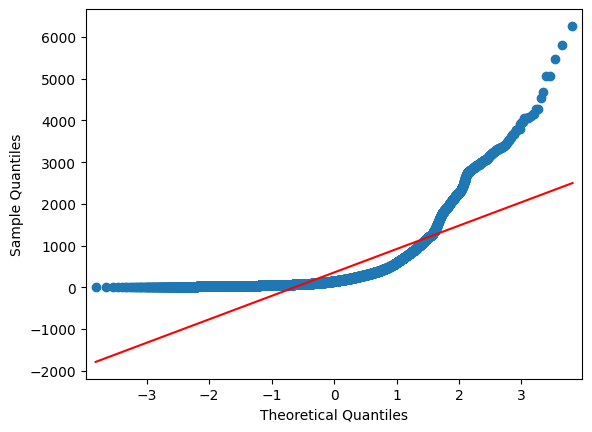

In [143]:
qqplot(data['actual_time'], line= 's')
plt.show()

# **osrm_time- QQTEST for normality**

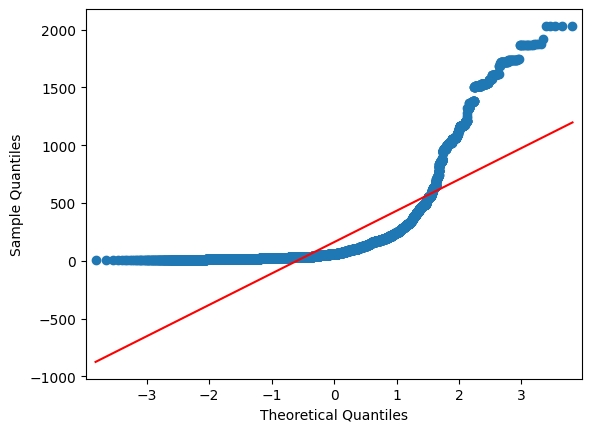

In [144]:
qqplot(data['osrm_time'], line= 's')
plt.show()

**From QQTEST we can see that the actual_time and OSRM_time do NOT follow normal distribution.**

# **Histplot/Kdeplot Test for Normality**

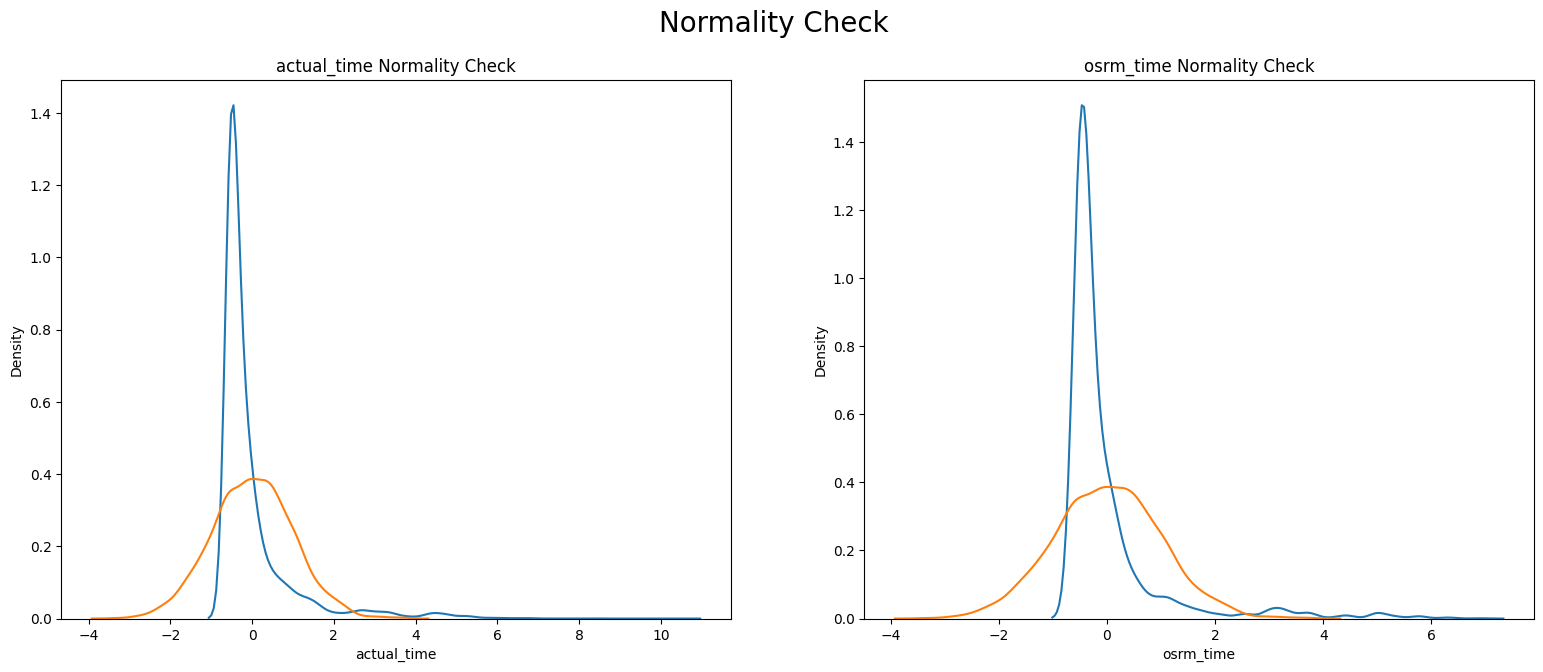

In [145]:
std_norm= np.random.normal(0, 1, 3000)

actual_time_z= zscore(data['actual_time'])
od_start_time_z= zscore(data['osrm_time'])

plt.figure(figsize = (19,7))
plt.suptitle('Normality Check', fontsize=20)

plt.subplot(1,2,1)
plt.title('actual_time Normality Check')
sns.kdeplot(actual_time_z)
sns.kdeplot(std_norm)

plt.subplot(1,2,2)
plt.title('osrm_time Normality Check')
sns.kdeplot(od_start_time_z)
sns.kdeplot(std_norm)
plt.show()

**From KDE PLOT we can see that the actual_time and OSRM_time do NOT follow normal distribution.**

# **Shapiro Test For Normality**

>$H_o:$ Data follows Gaussian distribution

>$H_a:$ Data do NOT follow Gaussian distribution

In [146]:
#actual_time
shapiro_stat , p_val = shapiro(data['actual_time'])
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.5803482377144945 , P_Value : 1.562468303558549e-103

Data Do NOT Follow Gaussian distribution


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14787.
  res = hypotest_fun_out(*samples, **kwds)


In [147]:
#actual_time
shapiro_stat , p_val = shapiro(data['osrm_time'])
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.5457228283773967 , P_Value : 1.4819529577293302e-105

Data Do NOT Follow Gaussian distribution


**We conclude that the samples do not follow normal distribution**

# **Variances Checks**

#**Levene’s test**

>$H_0$: All the count variances are equal

>$H_a$: At least one variance is different from the rest

In [148]:
levene_stat, p_val = levene(data['actual_time'], data['osrm_time'])
print(f"Levene_stat : {levene_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Has Similar Variance')
else:
	print('Data Do NOT Have Similar Variance')

Levene_stat : 1013.8463480511717 , P_Value : 8.743536461316657e-219

Data Do NOT Have Similar Variance


**We conclude that the 2 sample do not have same variance and are not normally distributed. T-Test cannot be applied here, we can perform its non parametric
equivalent test i.e., Mann-Whitney U rank test for two independent samples. But we will try to compare both tests.**

# **2-Sample Independent T-Test**

In [149]:
def test_result(p_value, alpha):
    if p_value < alpha:
        print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
    else:
        print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

**Two-Tailed Test**

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

In [150]:
test_stat, p_value = ttest_ind(data['actual_time'], data['osrm_time'], equal_var= False)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 38.080715677235965 , P_Value : 4.77849469915002e-307

As the p-value 4.77849469915002e-307 is less than the level of significance, we reject the null hypothesis.


**Test Result: We reject Null Hypothesis that means there is significant difference between actual_time and OSRM_time**

**One-Tailed Test**

$H_0: \mu_1  >  \mu_2$

$H_a: \mu_1  <  \mu_2$

In [151]:
test_stat, p_value = ttest_ind(data['actual_time'], data['osrm_time'], alternative= 'less', equal_var= False)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 38.080715677235965 , P_Value : 1.0

As the p-value 1.0 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means actual_time > OSRM_time**

# **MannWhitney u Rank test(Non-Parametric Test)**

$H_0: \mu_1  >  \mu_2$

$H_a: \mu_1  <  \mu_2$

In [152]:
test_stat, p_value = mannwhitneyu(data['actual_time'], data['osrm_time'], alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 152176575.5 , P_Value : 1.0

As the p-value 1.0 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means actual_time > OSRM_time**

# **2. Check if there any significant difference between the actual_time aggregated value and segment actual time aggregated value?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**b. Select an appropriate test -**

**i. Hint: 2- Sample Independent T-test**

**c. Set a significance level**

**i. Hint: alpha=5% is recommended**

**d. Calculate test Statistics / p-value**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.**

**f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define The Null And Alternate Hypothesis**


$H_0:$ The Actual aggregated time taken for delivery is SIMILAR to Segment Actual Time

$H_a:$ The Actual aggregated time taken for delivery is NOT SIMILAR to Segment Actual Time.

Let $\mu_1$ and $\mu_2$ be the average time taken for delivery respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

# **Step 2: Select An Appropriate Test**

We Can use Z-test or T-test as sample size if high. Population mean and std is not known. We will use 2 Sample T-test here.

**Assumptions of T-Test**
1. The sample size should be less than 30.
2. The population variance is unknown.
3. The population mean and standard deviation are finite.
4. The means of the two populations being compared should follow normal distributions.
5. If using Student's original definition of the t-test, the two populations being compared should have the same variance. If the sample sizes in the two groups being compared are equal, Student's original t-test is highly robust to the presence of unequal variances.


# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

**Normality checks:**

Distribution check using QQ Plot

Distribution check using Hist/Kde Plot

Confirmation by Shapiro-wilks Test

**Variances checks:**

Homogeneity of Variances using Levene's test

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: T-Stats

**Distribution**: T-Distribution

If data follows normal distribution we go with ttest_ind

Else we will go with Mannwhitney_u test (Non - Parametric test)

# **Step 5: Determine whether the test should be left-tailed, right-tailed, or two-tailed.**

We will perform two-tailed and later go with left or right tailed test after the results of two-tailed test, if needed.

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the t-stat value using the ttest function using scip.stats.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho


# **Normality Checks**

# **Actual_time- QQTEST for normality**

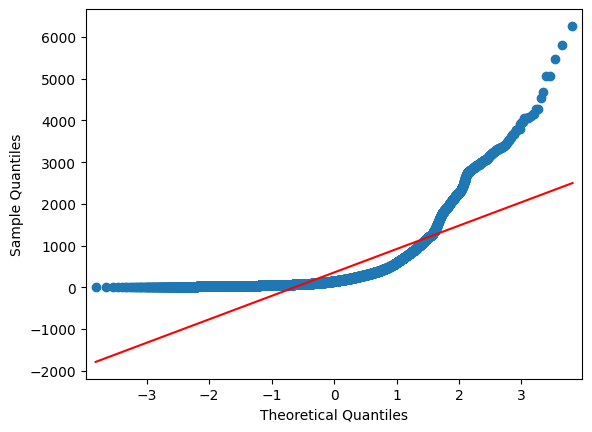

In [153]:
qqplot(data['actual_time'], line= 's')
plt.show()

# **segment_actual_time- QQTEST for normality**

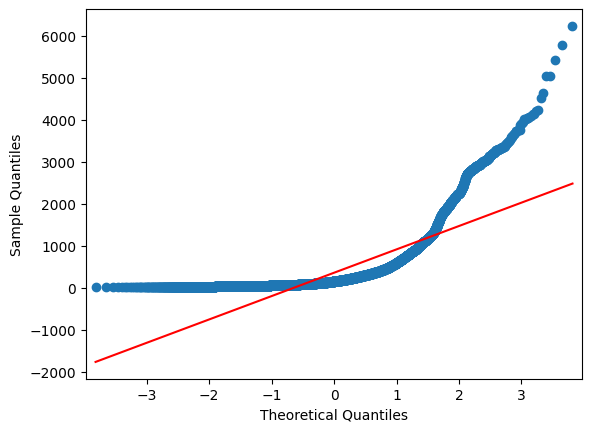

In [154]:
qqplot(data['segment_actual_time'], line= 's')
plt.show()

**From QQTEST we can see that both the samples do NOT follow normal distribution.**

# **Histplot/Kdeplot Test for Normality**

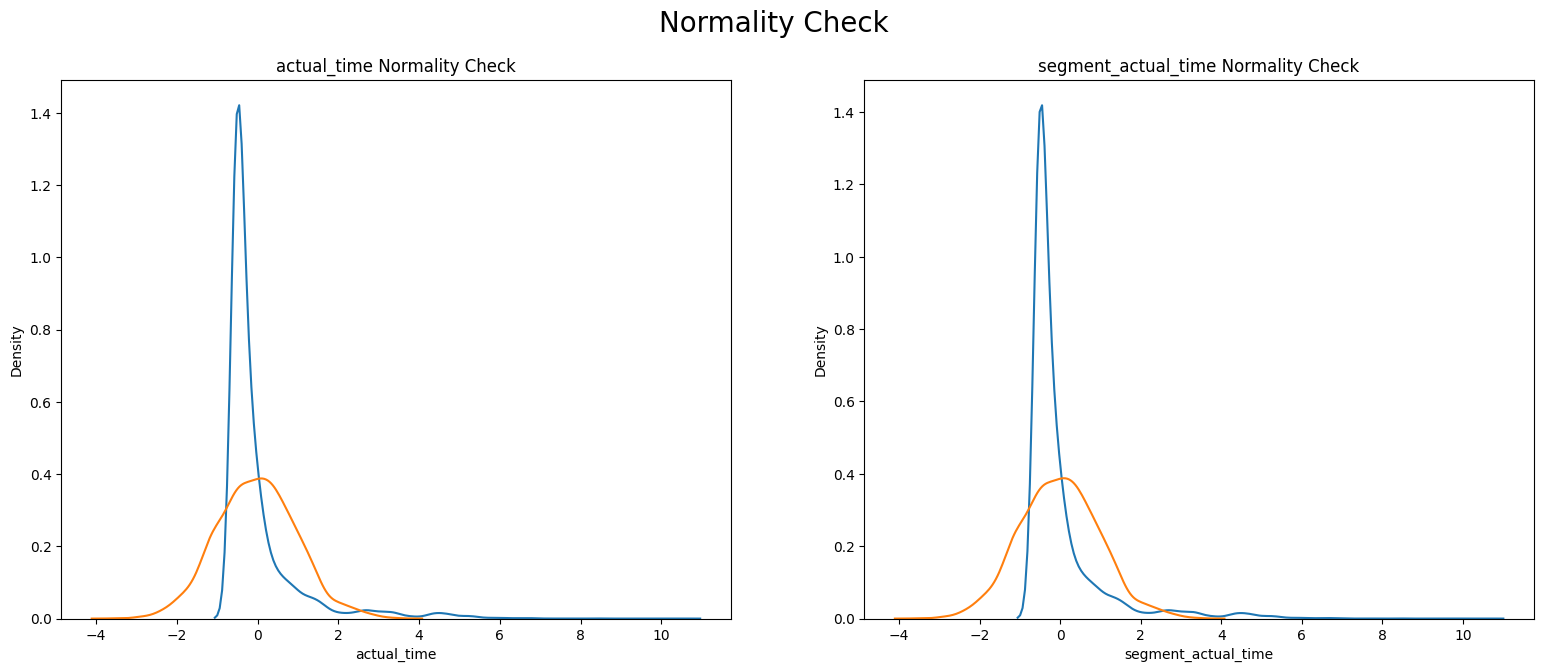

In [155]:
std_norm= np.random.normal(0, 1, 3000)

actual_time_z= zscore(data['actual_time'])
segment_actual_time_z= zscore(data['segment_actual_time'])

plt.figure(figsize = (19,7))
plt.suptitle('Normality Check', fontsize=20)

plt.subplot(1,2,1)
plt.title('actual_time Normality Check')
sns.kdeplot(actual_time_z)
sns.kdeplot(std_norm)

plt.subplot(1,2,2)
plt.title('segment_actual_time Normality Check')
sns.kdeplot(segment_actual_time_z)
sns.kdeplot(std_norm)
plt.show()

**From KDE PLOT we can see that both the samples do NOT follow normal distribution.**

# **Shapiro Test For Normality**

>$H_o:$ Data follows Gaussian distribution

>$H_a:$ Data do NOT follow Gaussian distribution

In [156]:
#actual_time
shapiro_stat , p_val = shapiro(data['actual_time'])
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.5803482377144945 , P_Value : 1.562468303558549e-103

Data Do NOT Follow Gaussian distribution


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14787.
  res = hypotest_fun_out(*samples, **kwds)


In [157]:
#segment_actual_time
shapiro_stat , p_val = shapiro(data['segment_actual_time'])
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.5808456330535781 , P_Value : 1.6746386852473887e-103

Data Do NOT Follow Gaussian distribution


**We can see from Shapiro-Wilk’s test both the samples do NOT follow normal distribution**

# **Variances Checks**

#**Levene’s test**

>$H_0$: All the count variances are equal

>$H_a$: At least one variance is different from the rest

In [158]:
levene_stat, p_val = levene(data['actual_time'], data['segment_actual_time'])
print(f"Levene_stat : {levene_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Has Similar Variance')
else:
	print('Data Do NOT Have Similar Variance')

Levene_stat : 0.1523862392501683 , P_Value : 0.6962681452003544

Data Has Similar Variance


**We conclude that the 2 sample do not have same variance and are not normally distributed. T-Test cannot be applied here, we can perform its non parametric
equivalent test i.e., Mann-Whitney U rank test for two independent samples. But we will try to compare both tests.**

# **2-Sample Independent T-Test**

**Two-Tailed Test**

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

In [159]:
test_stat, p_value = ttest_ind(data['actual_time'], data['segment_actual_time'], equal_var= False)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 0.499475764573994 , P_Value : 0.6174479722864479

As the p-value 0.6174479722864479 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We reject Null Hypothesis that means there is significant difference between actual_time and segment_actual_time**

**One-Tailed Test**

$H_0: \mu_1  >  \mu_2$

$H_a: \mu_1  <  \mu_2$

In [160]:
test_stat, p_value = ttest_ind(data['actual_time'], data['segment_actual_time'], equal_var= False, alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 0.499475764573994 , P_Value : 0.6912760138567761

As the p-value 0.6912760138567761 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means actual_time > segment_actual_time**

# **MannWhitney u Rank test(Non-Parametric Test)**

$H_0: \mu_1  >  \mu_2$

$H_a: \mu_1  <  \mu_2$

In [161]:
test_stat, p_value = mannwhitneyu(data['actual_time'], data['segment_actual_time'], alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 109925053.5 , P_Value : 0.7921073806132161

As the p-value 0.7921073806132161 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means actual_time > segment_actual_time**

# **3. Check if there any significant difference between the OSRM distance aggregated value and segment OSRM distance?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**b. Select an appropriate test -**

**i. Hint: 2- Sample Independent T-test**

**c. Set a significance level**

**i. Hint: alpha=5% is recommended**

**d. Calculate test Statistics / p-value**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.**

**f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define The Null And Alternate Hypothesis**


$H_0:$ The Actual osrm_distance for delivery is SIMILAR to segment_osrm_distance.

$H_a:$ The Actual osrm_distance for delivery is NOT SIMILAR to segment_osrm_distance.

Let $\mu_1$ and $\mu_2$ be the average time taken for delivery respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

# **Step 2: Select An Appropriate Test**

We Can use Z-test or T-test as sample size if high. Population mean and std is not known. We will use 2 Sample T-test here.

**Assumptions of T-Test**
1. The sample size should be less than 30.
2. The population variance is unknown.
3. The population mean and standard deviation are finite.
4. The means of the two populations being compared should follow normal distributions.
5. If using Student's original definition of the t-test, the two populations being compared should have the same variance. If the sample sizes in the two groups being compared are equal, Student's original t-test is highly robust to the presence of unequal variances.


# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

**Normality checks:**

Distribution check using QQ Plot

Distribution check using Hist/Kde Plot

Confirmation by Shapiro-wilks Test

**Variances checks:**

Homogeneity of Variances using Levene's test

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: T-Stats

**Distribution**: T-Distribution

If data follows normal distribution we go with ttest_ind

Else we will go with Mannwhitney_u test (Non - Parametric test)

# **Step 5: Determine whether the test should be left-tailed, right-tailed, or two-tailed.**

We will perform two-tailed and later go with left or right tailed test after the results of two-tailed test, if needed.

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the t-stat value using the ttest function using scip.stats.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho


# **Normality Checks**

# **osrm_distance- QQTEST for normality**

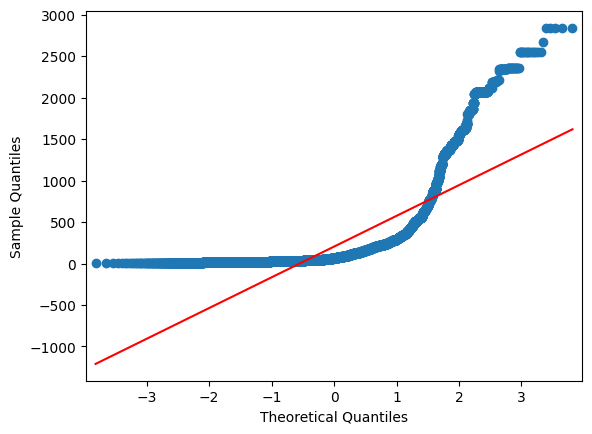

In [162]:
qqplot(data['osrm_distance'], line= 's')
plt.show()

# **segment_osrm_distance- QQTEST for normality**

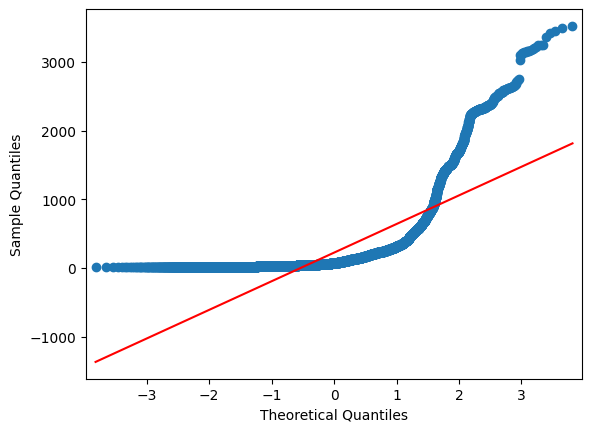

In [163]:
qqplot(data['segment_osrm_distance'], line= 's')
plt.show()

**From QQTEST we can see that the OSRM_distance and segment_OSRM_distance do NOT follow normal distribution.**

# **Histplot/Kdeplot Test for Normality**

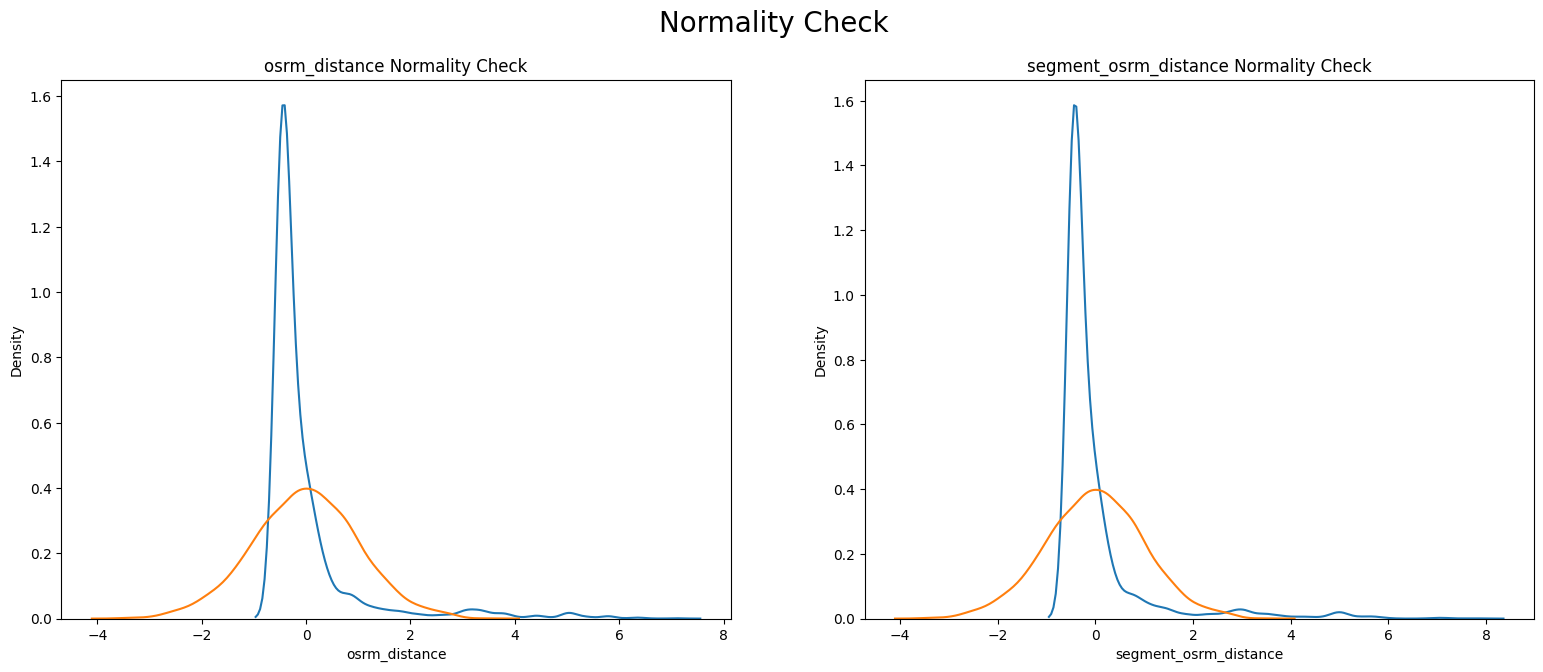

In [164]:
std_norm= np.random.normal(0, 1, 3000)

osrm_distance_z= zscore(data['osrm_distance'])
segment_osrm_distance_z= zscore(data['segment_osrm_distance'])

plt.figure(figsize = (19,7))
plt.suptitle('Normality Check', fontsize=20)

plt.subplot(1,2,1)
plt.title('osrm_distance Normality Check')
sns.kdeplot(osrm_distance_z)
sns.kdeplot(std_norm)

plt.subplot(1,2,2)
plt.title('segment_osrm_distance Normality Check')
sns.kdeplot(segment_osrm_distance_z)
sns.kdeplot(std_norm)
plt.show()

**From KDE PLOT we can see that the OSRM_distance and segment_OSRM_distance do NOT follow normal distribution.**

# **Shapiro Test For Normality**

>$H_o:$ Data follows Gaussian distribution

>$H_a:$ Data do NOT follow Gaussian distribution

In [165]:
#osrm_distance
shapiro_stat , p_val = shapiro(data['osrm_distance'])
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.5216464222773737 , P_Value : 6.956667209921968e-107

Data Do NOT Follow Gaussian distribution


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14787.
  res = hypotest_fun_out(*samples, **kwds)


In [166]:
#segment_osrm_distance
shapiro_stat , p_val = shapiro(data['segment_osrm_distance'])
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.5071258876719175 , P_Value : 1.1730299870402527e-107

Data Do NOT Follow Gaussian distribution


**We conclude that the samples do not follow normal distribution**

# **Variances Checks**

#**Levene’s test**

>$H_0$: All the count variances are equal

>$H_a$: At least one variance is different from the rest

In [167]:
levene_stat, p_val = levene(data['osrm_distance'], data['segment_osrm_distance'])
print(f"Levene_stat : {levene_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Has Similar Variance')
else:
	print('Data Do NOT Have Similar Variance')

Levene_stat : 13.640878396710558 , P_Value : 0.00022171213513990103

Data Do NOT Have Similar Variance


**We conclude that the 2 sample do not have same variance and are not normally distributed. T-Test cannot be applied here, we can perform its non parametric
equivalent test i.e., Mann-Whitney U rank test for two independent samples. But we will try to compare both tests.**

# **2-Sample Independent T-Test**

**Two-Tailed Test**

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

In [168]:
test_stat, p_value = ttest_ind(data['osrm_distance'], data['segment_osrm_distance'], equal_var= False)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : -4.102786976805514 , P_Value : 4.093107924446193e-05

As the p-value 4.093107924446193e-05 is less than the level of significance, we reject the null hypothesis.


**Test Result: We reject Null Hypothesis that means there is significant difference between OSRM_distance and segment_OSRM_distance**

**One-Tailed Test**

$H_0: \mu_1  >  \mu_2$

$H_a: \mu_1  <  \mu_2$

In [169]:
test_stat, p_value = ttest_ind(data['osrm_distance'], data['segment_osrm_distance'], equal_var= False, alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : -4.102786976805514 , P_Value : 2.0465539622230965e-05

As the p-value 2.0465539622230965e-05 is less than the level of significance, we reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means OSRM_distance > segment_OSRM_distance**

# **MannWhitney u Rank test(Non-Parametric Test)**

$H_0: \mu_1  >  \mu_2$

$H_a: \mu_1  <  \mu_2$

In [170]:
test_stat, p_value = mannwhitneyu(data['osrm_distance'], data['segment_osrm_distance'], alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 105736776.0 , P_Value : 5.000543829546036e-07

As the p-value 5.000543829546036e-07 is less than the level of significance, we reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means OSRM_distance > segment_OSRM_distance**

# **4. Check if there any significant difference between osrm_time and segment_osrm_time?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**b. Select an appropriate test -**

**i. Hint: 2- Sample Independent T-test**

**c. Set a significance level**

**i. Hint: alpha=5% is recommended**

**d. Calculate test Statistics / p-value**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.**

**f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define The Null And Alternate Hypothesis**

$H_0:$ The segment_osrm_time taken for delivery is SIMILAR to OSRM time aggregated.

$H_a:$ The segment_osrm_time taken for delivery is NOT SIMILAR to OSRM time aggregated.

Let $\mu_1$ and $\mu_2$ be the average time taken for delivery respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

# **Step 2: Select An Appropriate Test**

We Can use Z-test or T-test as sample size if high. Population mean and std is not known. We will use 2 Sample T-test here.

**Assumptions of T-Test**
1. The sample size should be less than 30.
2. The population variance is unknown.
3. The population mean and standard deviation are finite.
4. The means of the two populations being compared should follow normal distributions.
5. If using Student's original definition of the t-test, the two populations being compared should have the same variance. If the sample sizes in the two groups being compared are equal, Student's original t-test is highly robust to the presence of unequal variances.


# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

**Normality checks:**

Distribution check using QQ Plot

Distribution check using Hist/Kde Plot

Confirmation by Shapiro-wilks Test

**Variances checks:**

Homogeneity of Variances using Levene's test

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: T-Stats

**Distribution**: T-Distribution

If data follows normal distribution we go with ttest_ind

Else we will go with Mannwhitney_u test (Non - Parametric test)

# **Step 5: Determine whether the test should be left-tailed, right-tailed, or two-tailed.**

We will perform two-tailed and later go with left or right tailed test after the results of two-tailed test, if needed.

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the t-stat value using the ttest function using scip.stats.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho


# **Normality Checks**

# **osrm_time- QQTEST for normality**

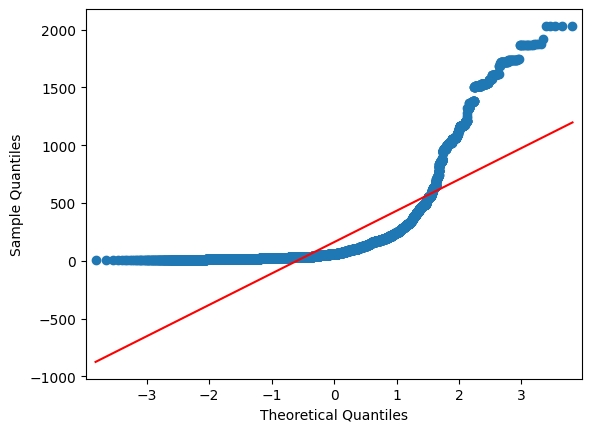

In [171]:
qqplot(data['osrm_time'], line= 's')
plt.show()

# **segment_osrm_time- QQTEST for normality**

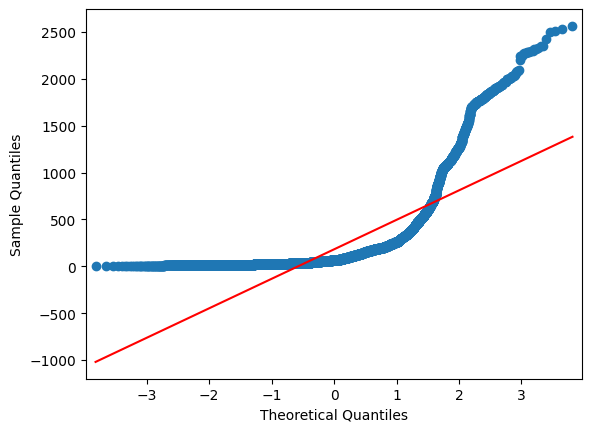

In [172]:
qqplot(data['segment_osrm_time'], line= 's')
plt.show()

**From QQTEST we can see that the segment_OSRM_time and OSRM_time do NOT follow normal distribution.**

# **Histplot/Kdeplot Test for Normality**

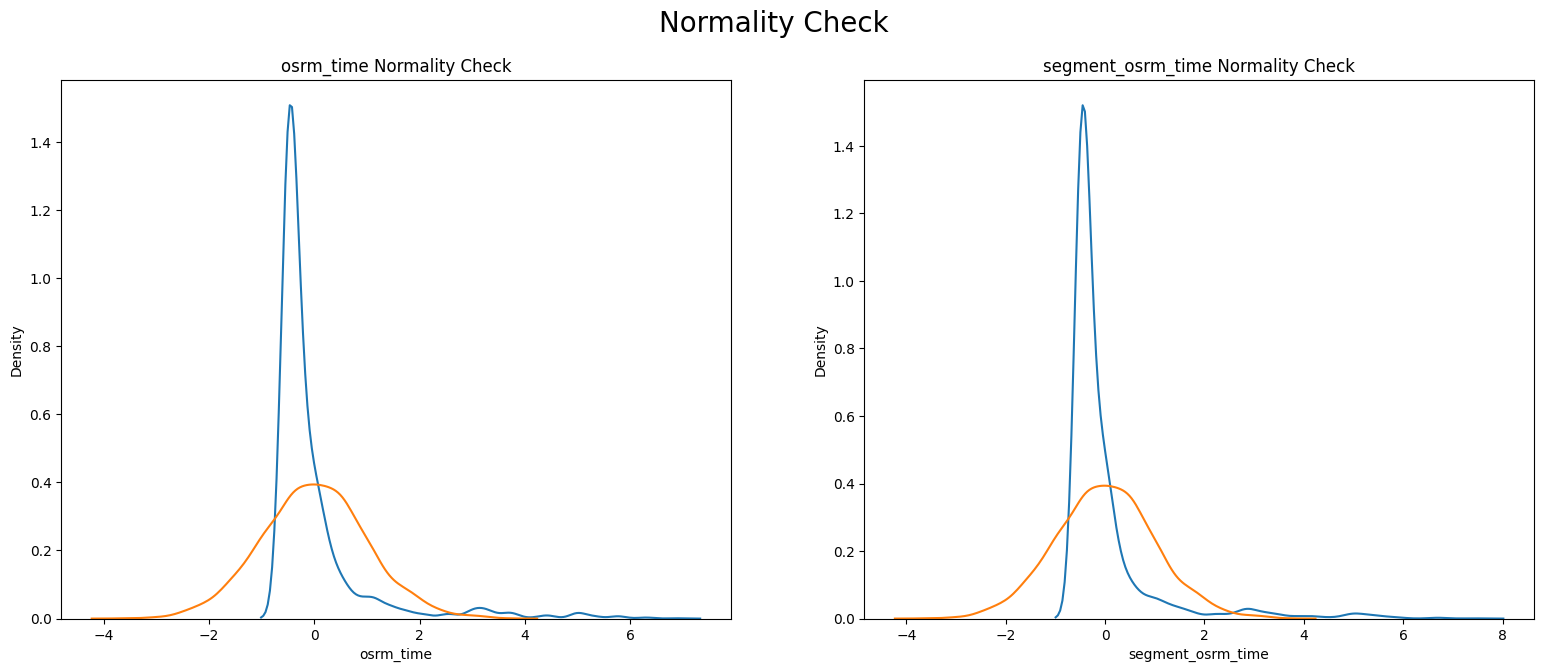

In [173]:
std_norm= np.random.normal(0, 1, 3000)

osrm_time_z= zscore(data['osrm_time'])
segment_osrm_time_z= zscore(data['segment_osrm_time'])

plt.figure(figsize = (19,7))
plt.suptitle('Normality Check', fontsize=20)

plt.subplot(1,2,1)
plt.title('osrm_time Normality Check')
sns.kdeplot(osrm_time_z)
sns.kdeplot(std_norm)

plt.subplot(1,2,2)
plt.title('segment_osrm_time Normality Check')
sns.kdeplot(segment_osrm_time_z)
sns.kdeplot(std_norm)
plt.show()

**From KDE PLOT we can see that the segment_OSRM_time and OSRM_time do NOT follow normal distribution.**

# **Shapiro Test For Normality**

>$H_o:$ Data follows Gaussian distribution

>$H_a:$ Data do NOT follow Gaussian distribution

In [174]:
#actual_time
shapiro_stat , p_val = shapiro(data['osrm_time'])
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.5457228283773967 , P_Value : 1.4819529577293302e-105

Data Do NOT Follow Gaussian distribution


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14787.
  res = hypotest_fun_out(*samples, **kwds)


In [175]:
#actual_time
shapiro_stat , p_val = shapiro(data['segment_osrm_time'])
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.5317562992725007 , P_Value : 2.4712371662349414e-106

Data Do NOT Follow Gaussian distribution


**We conclude that the samples do not follow normal distribution**

# **Variances Checks**

#**Levene’s test**

>$H_0$: All the count variances are equal

>$H_a$: At least one variance is different from the rest

In [176]:
levene_stat, p_val = levene(data['osrm_time'], data['segment_osrm_time'])
print(f"Levene_stat : {levene_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Has Similar Variance')
else:
	print('Data Do NOT Have Similar Variance')

Levene_stat : 28.53905343143278 , P_Value : 9.250556006347759e-08

Data Do NOT Have Similar Variance


**We conclude that the 2 sample do not have same variance and are not normally distributed. T-Test cannot be applied here, we can perform its non parametric
equivalent test i.e., Mann-Whitney U rank test for two independent samples. But we will try to compare both tests.**

# **2-Sample Independent T-Test**

**Two-Tailed Test**

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

In [177]:
test_stat, p_value = ttest_ind(data['osrm_time'], data['segment_osrm_time'], equal_var= False)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : -5.711782161676085 , P_Value : 1.1289348773479396e-08

As the p-value 1.1289348773479396e-08 is less than the level of significance, we reject the null hypothesis.


**Test Result: We reject Null Hypothesis that means there is significant difference between segment_osrm_time and OSRM_time**

**One-Tailed Test**

$H_0: \mu_1  >  \mu_2$

$H_a: \mu_1  <  \mu_2$

In [178]:
test_stat, p_value = ttest_ind(data['osrm_time'], data['segment_osrm_time'], equal_var= False, alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : -5.711782161676085 , P_Value : 5.644674386739698e-09

As the p-value 5.644674386739698e-09 is less than the level of significance, we reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means osrm_time > segment_osrm_time**

# **MannWhitney u Rank test(Non-Parametric Test)**

$H_0: \mu_1  >  \mu_2$

$H_a: \mu_1  <  \mu_2$

In [179]:
test_stat, p_value = mannwhitneyu(data['osrm_time'], data['segment_osrm_time'], alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 105235964.5 , P_Value : 1.2446765795661789e-08

As the p-value 1.2446765795661789e-08 is less than the level of significance, we reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means osrm_time > segment_osrm_time**

# **5. In-Depth Analysis**

**Univariate Analysis**

**Categorical Distribution**

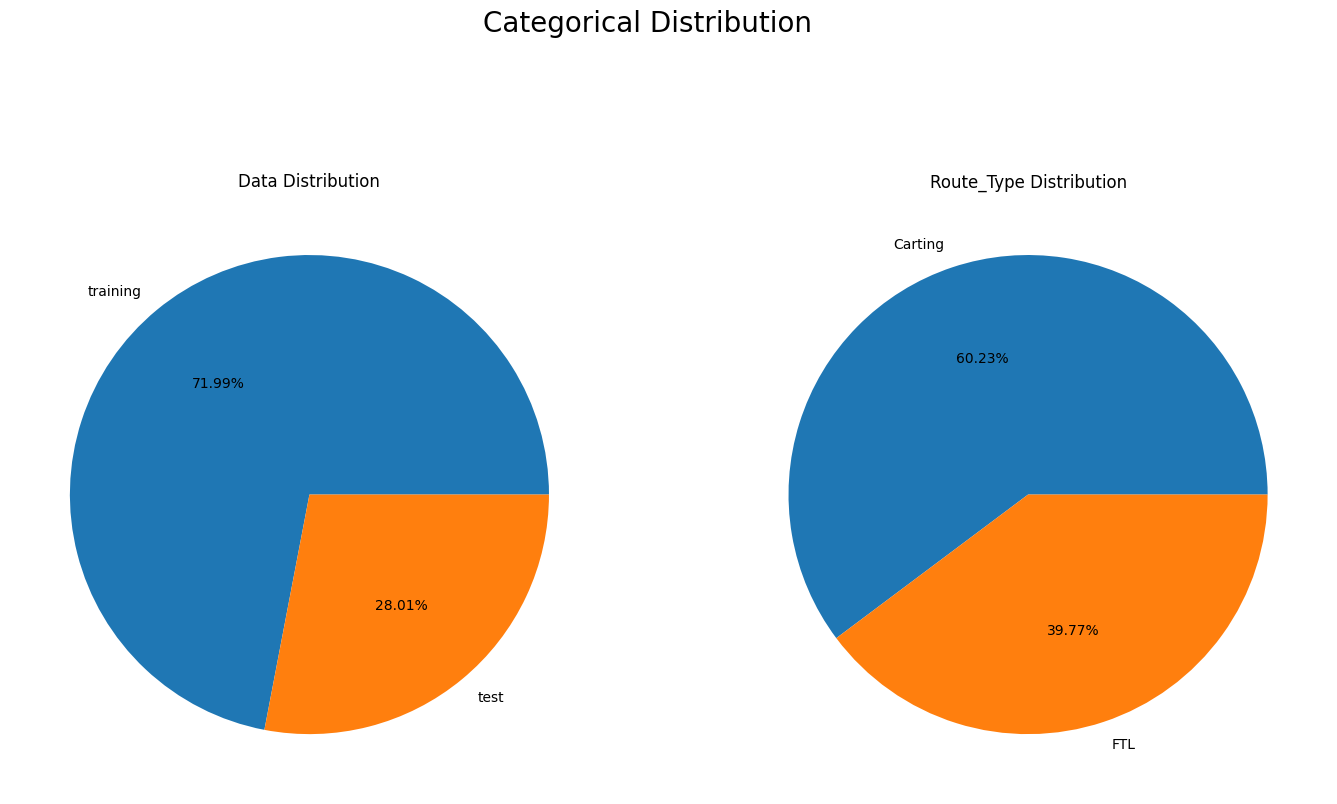

In [180]:
cat_cols= data.select_dtypes('category').columns
plt.figure(figsize=(17,10))
for j,i in enumerate(cat_cols):
    plt.subplot(1,2,j+1)
    plt.title(f'{i.title()} Distribution')
    value= data[i].value_counts()
    type_data= data[i].value_counts().index
    plt.pie(value, labels= type_data, autopct= '%2.2f%%')
plt.suptitle('Categorical Distribution', fontsize=20)
plt.show()

*>**Insight:** Test data is 28.01%, traning data is 71.99% in data category.
FTL is 39.77% and Carting is 60.23% in Route type category*

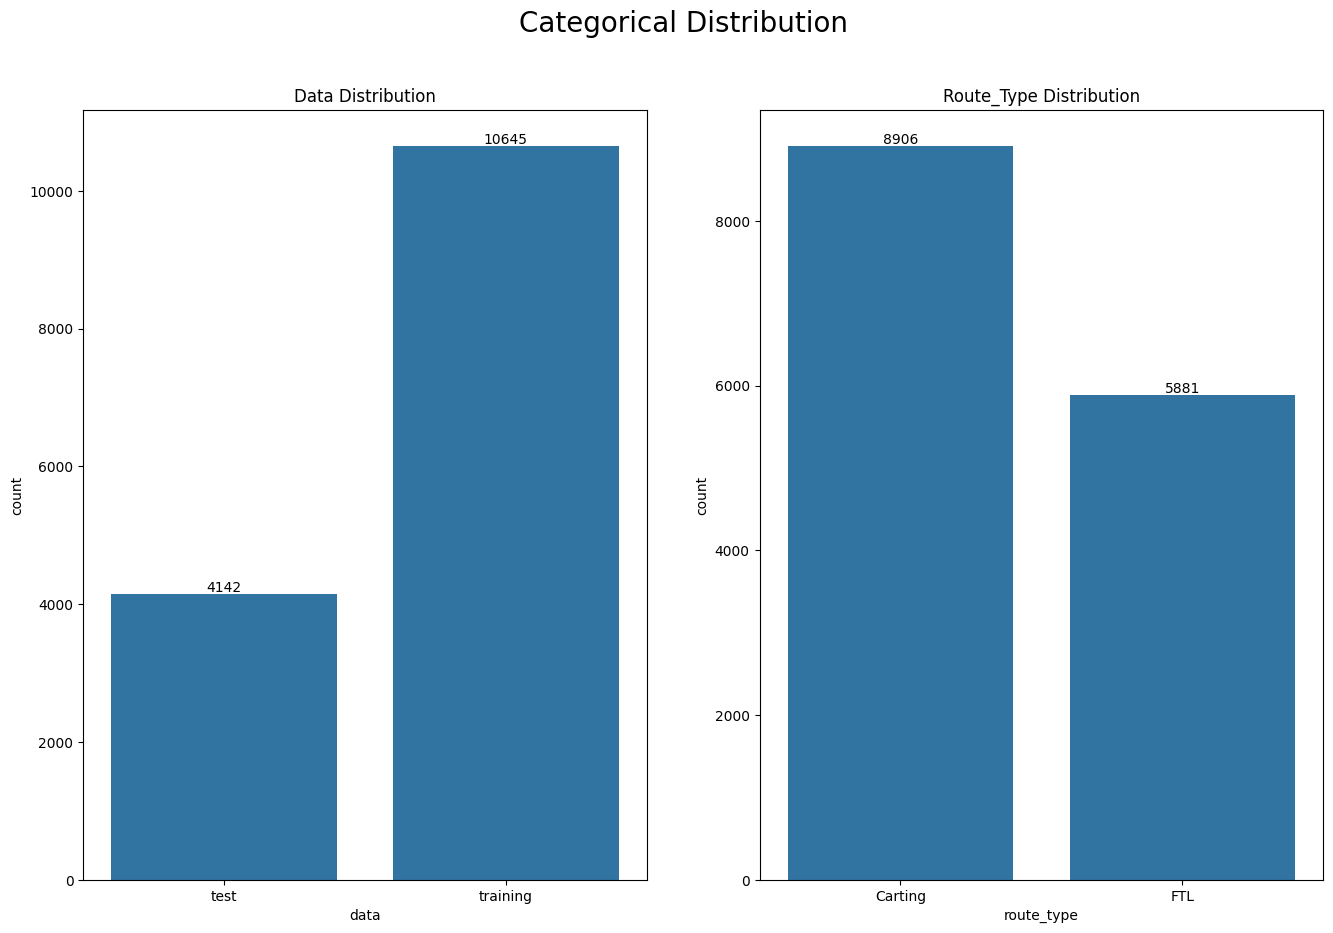

In [181]:
plt.figure(figsize=(16,10))
for j,i in enumerate(cat):
    plt.subplot(1,2,j+1)
    plt.title(f'{i.title()} Distribution')
    ax= sns.countplot(data, x= i)
    ax.bar_label(ax.containers[0])
plt.suptitle('Categorical Distribution', fontsize=20)
plt.show()

*>**Insight:** Test data has 4142 count, traning data is 10645 count in data category.
FTL is 5881 and Carting is 8906 in Route type category*

**Continuous Distribution**

**Distribution of Numerical Variables**

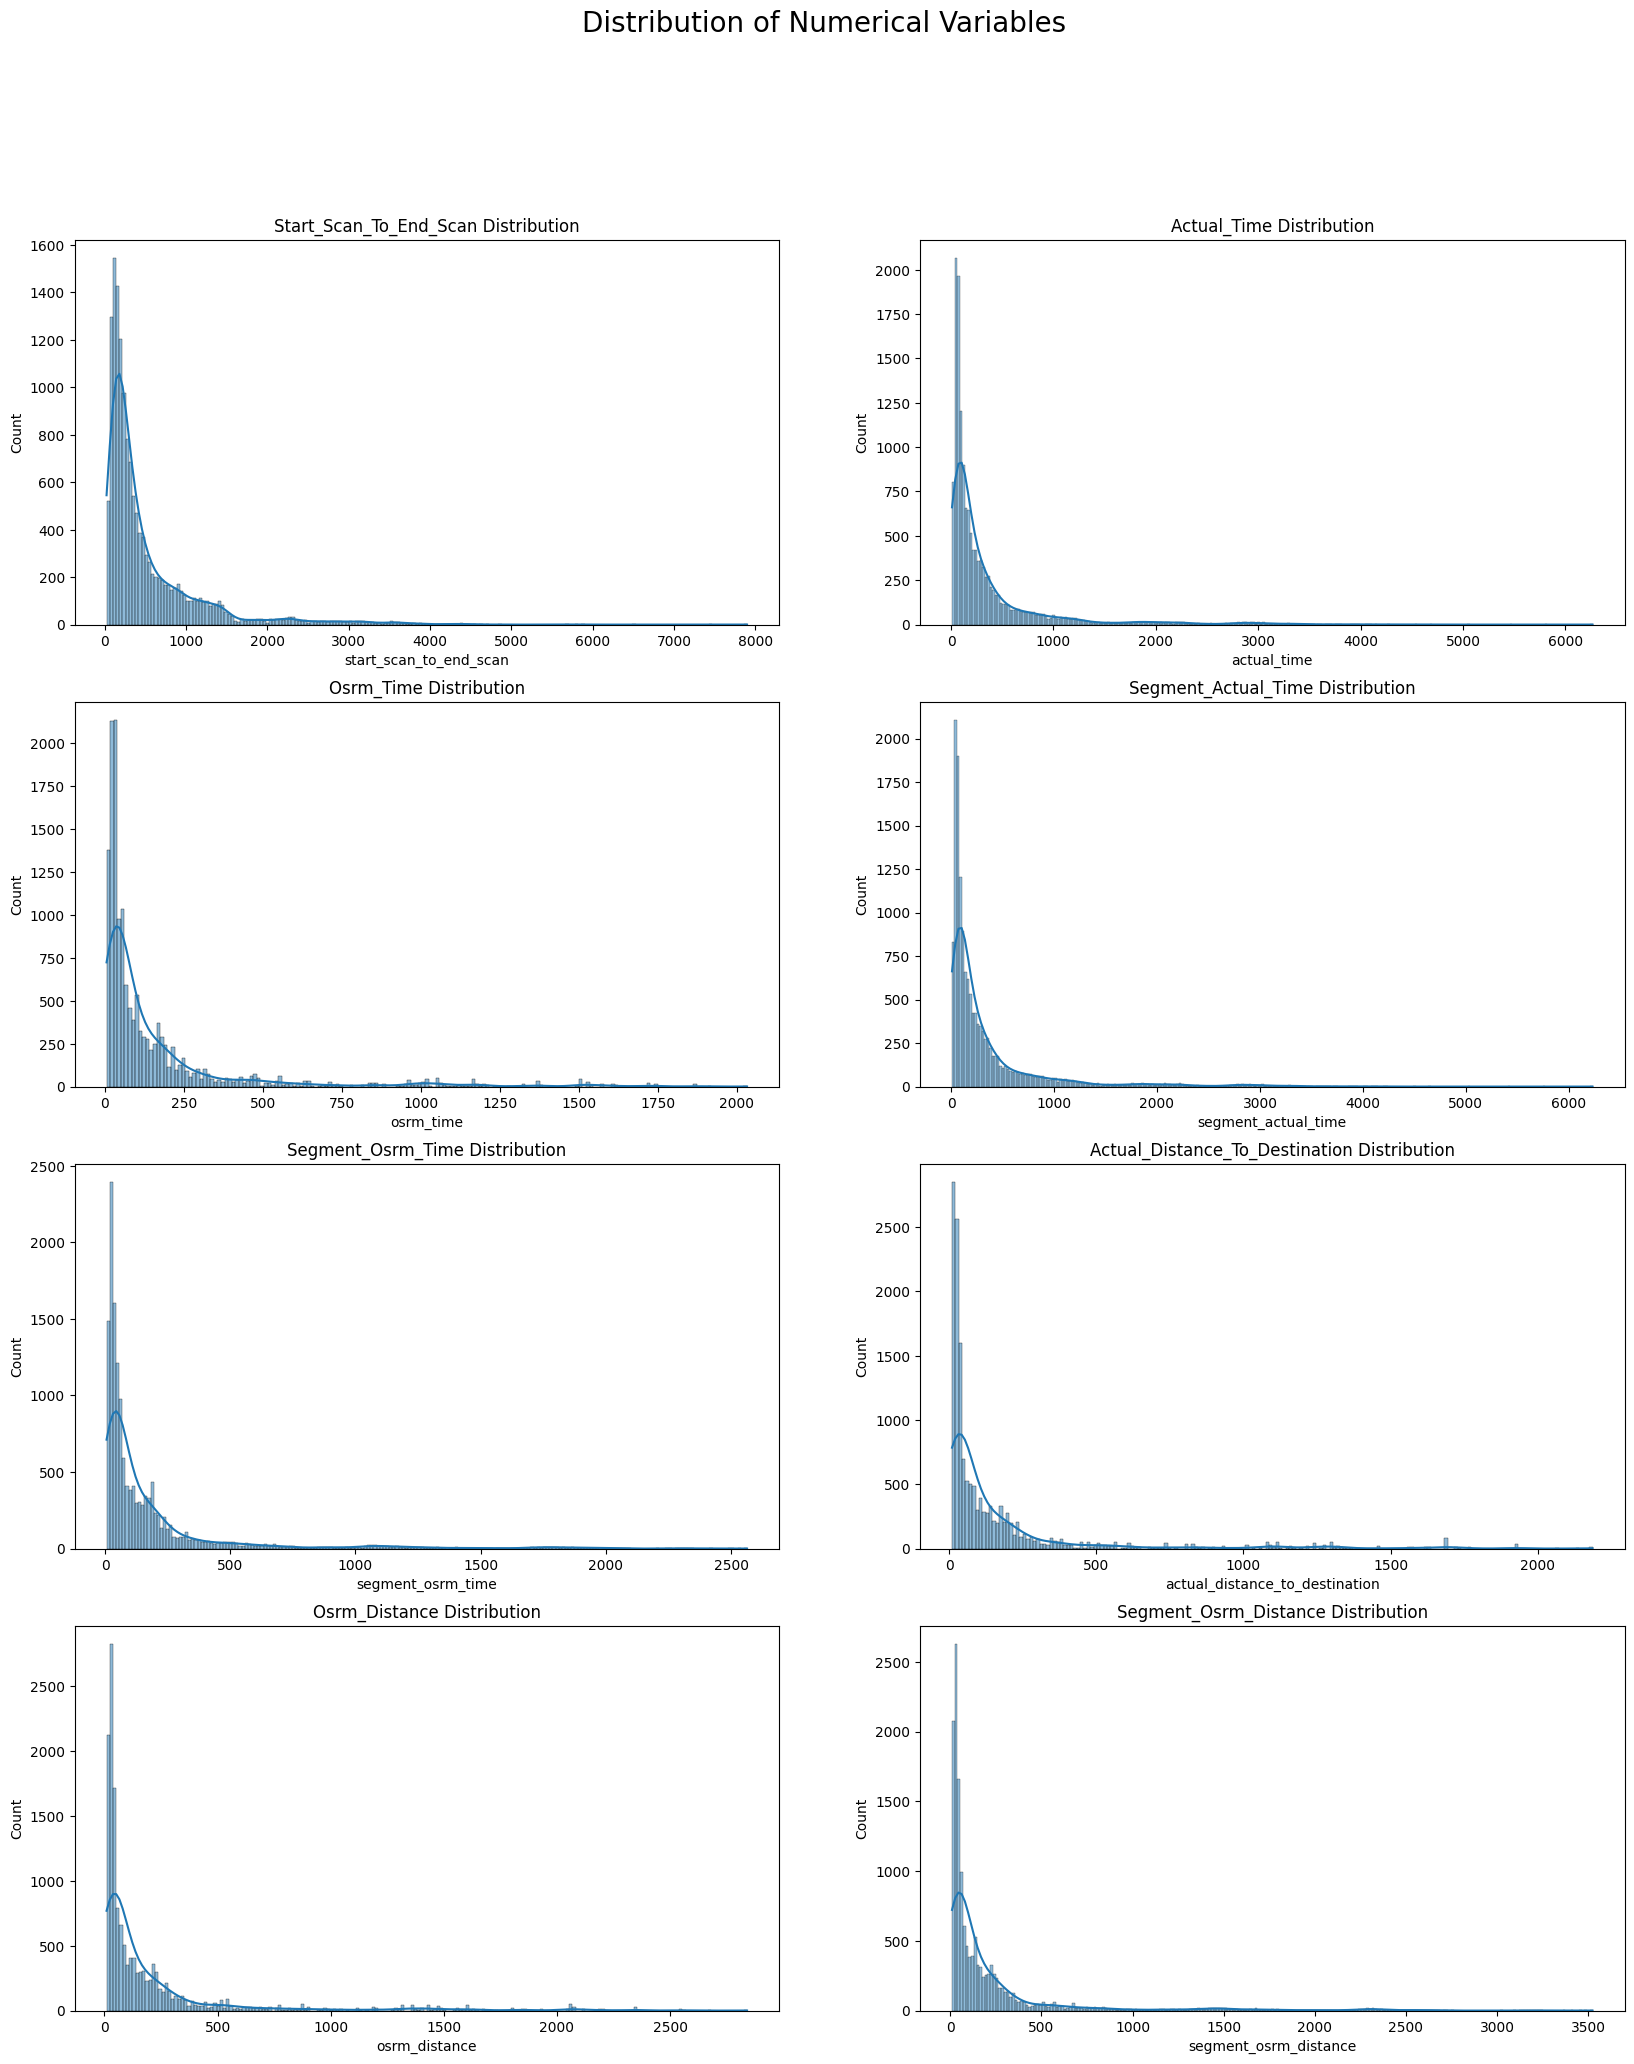

In [182]:
num_cols= data.select_dtypes('number').columns[:-4]
plt.figure(figsize=(20,23)).suptitle("Distribution of Numerical Variables", fontsize=20)
for j,i in enumerate(num_cols):
    plt.subplot(4,2,j+1)
    plt.title(f'{i.title()} Distribution')
    sns.histplot(data, x= i, kde=True)
plt.show()

*>**Insight:** All the num cols are right skewed*

<Axes: >

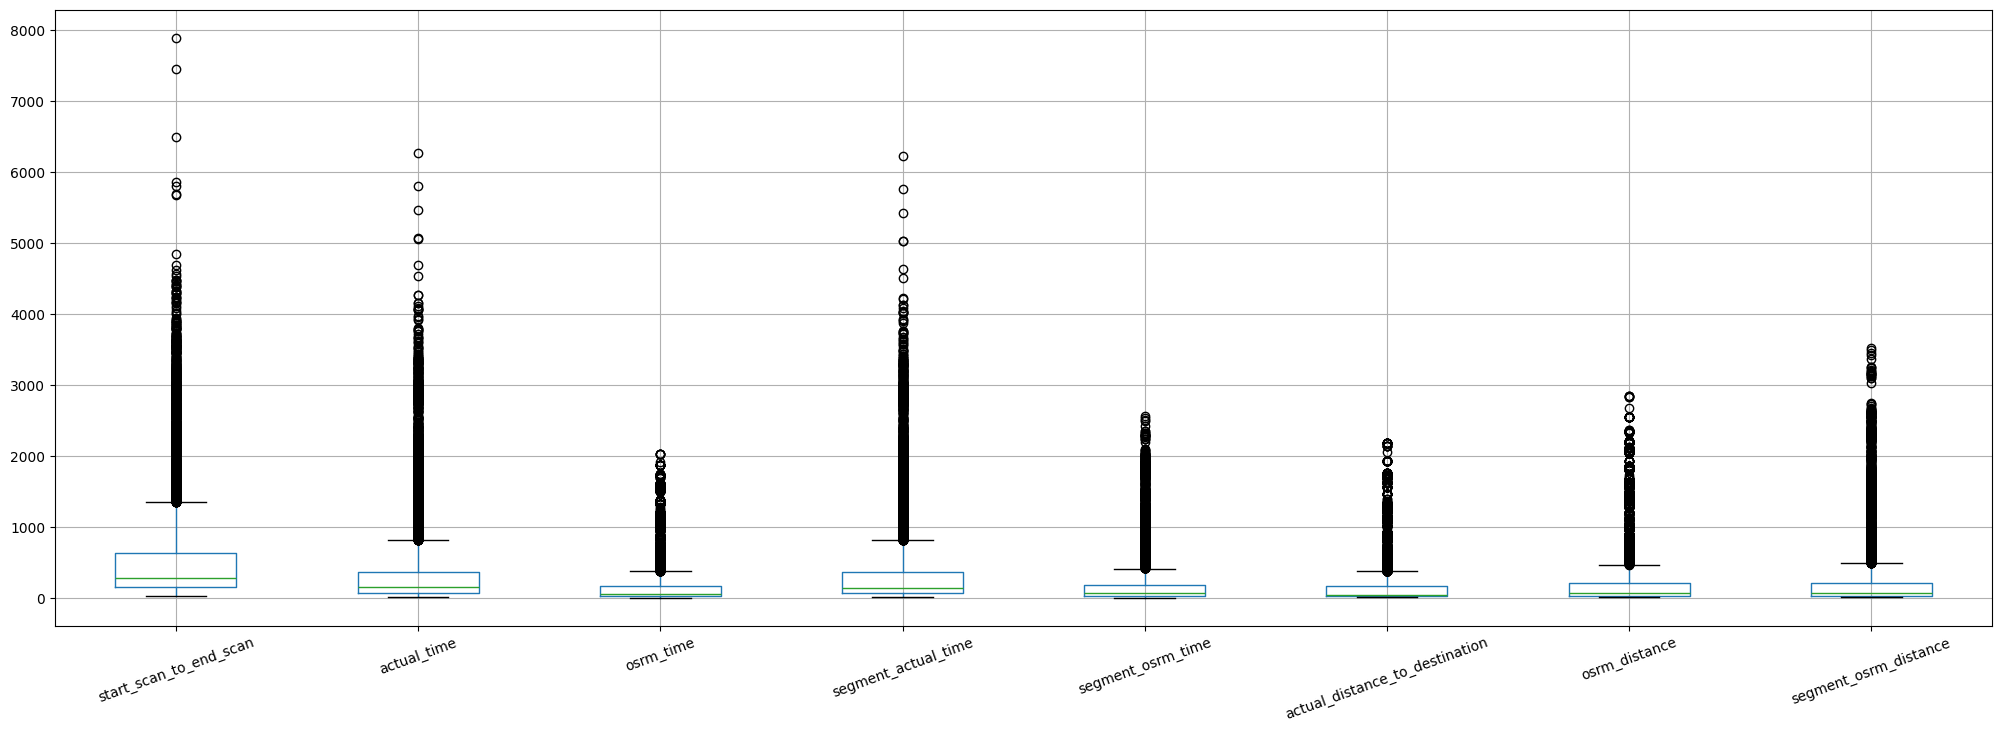

In [183]:
data[num_cols].boxplot(rot= 20,figsize=(25,8))

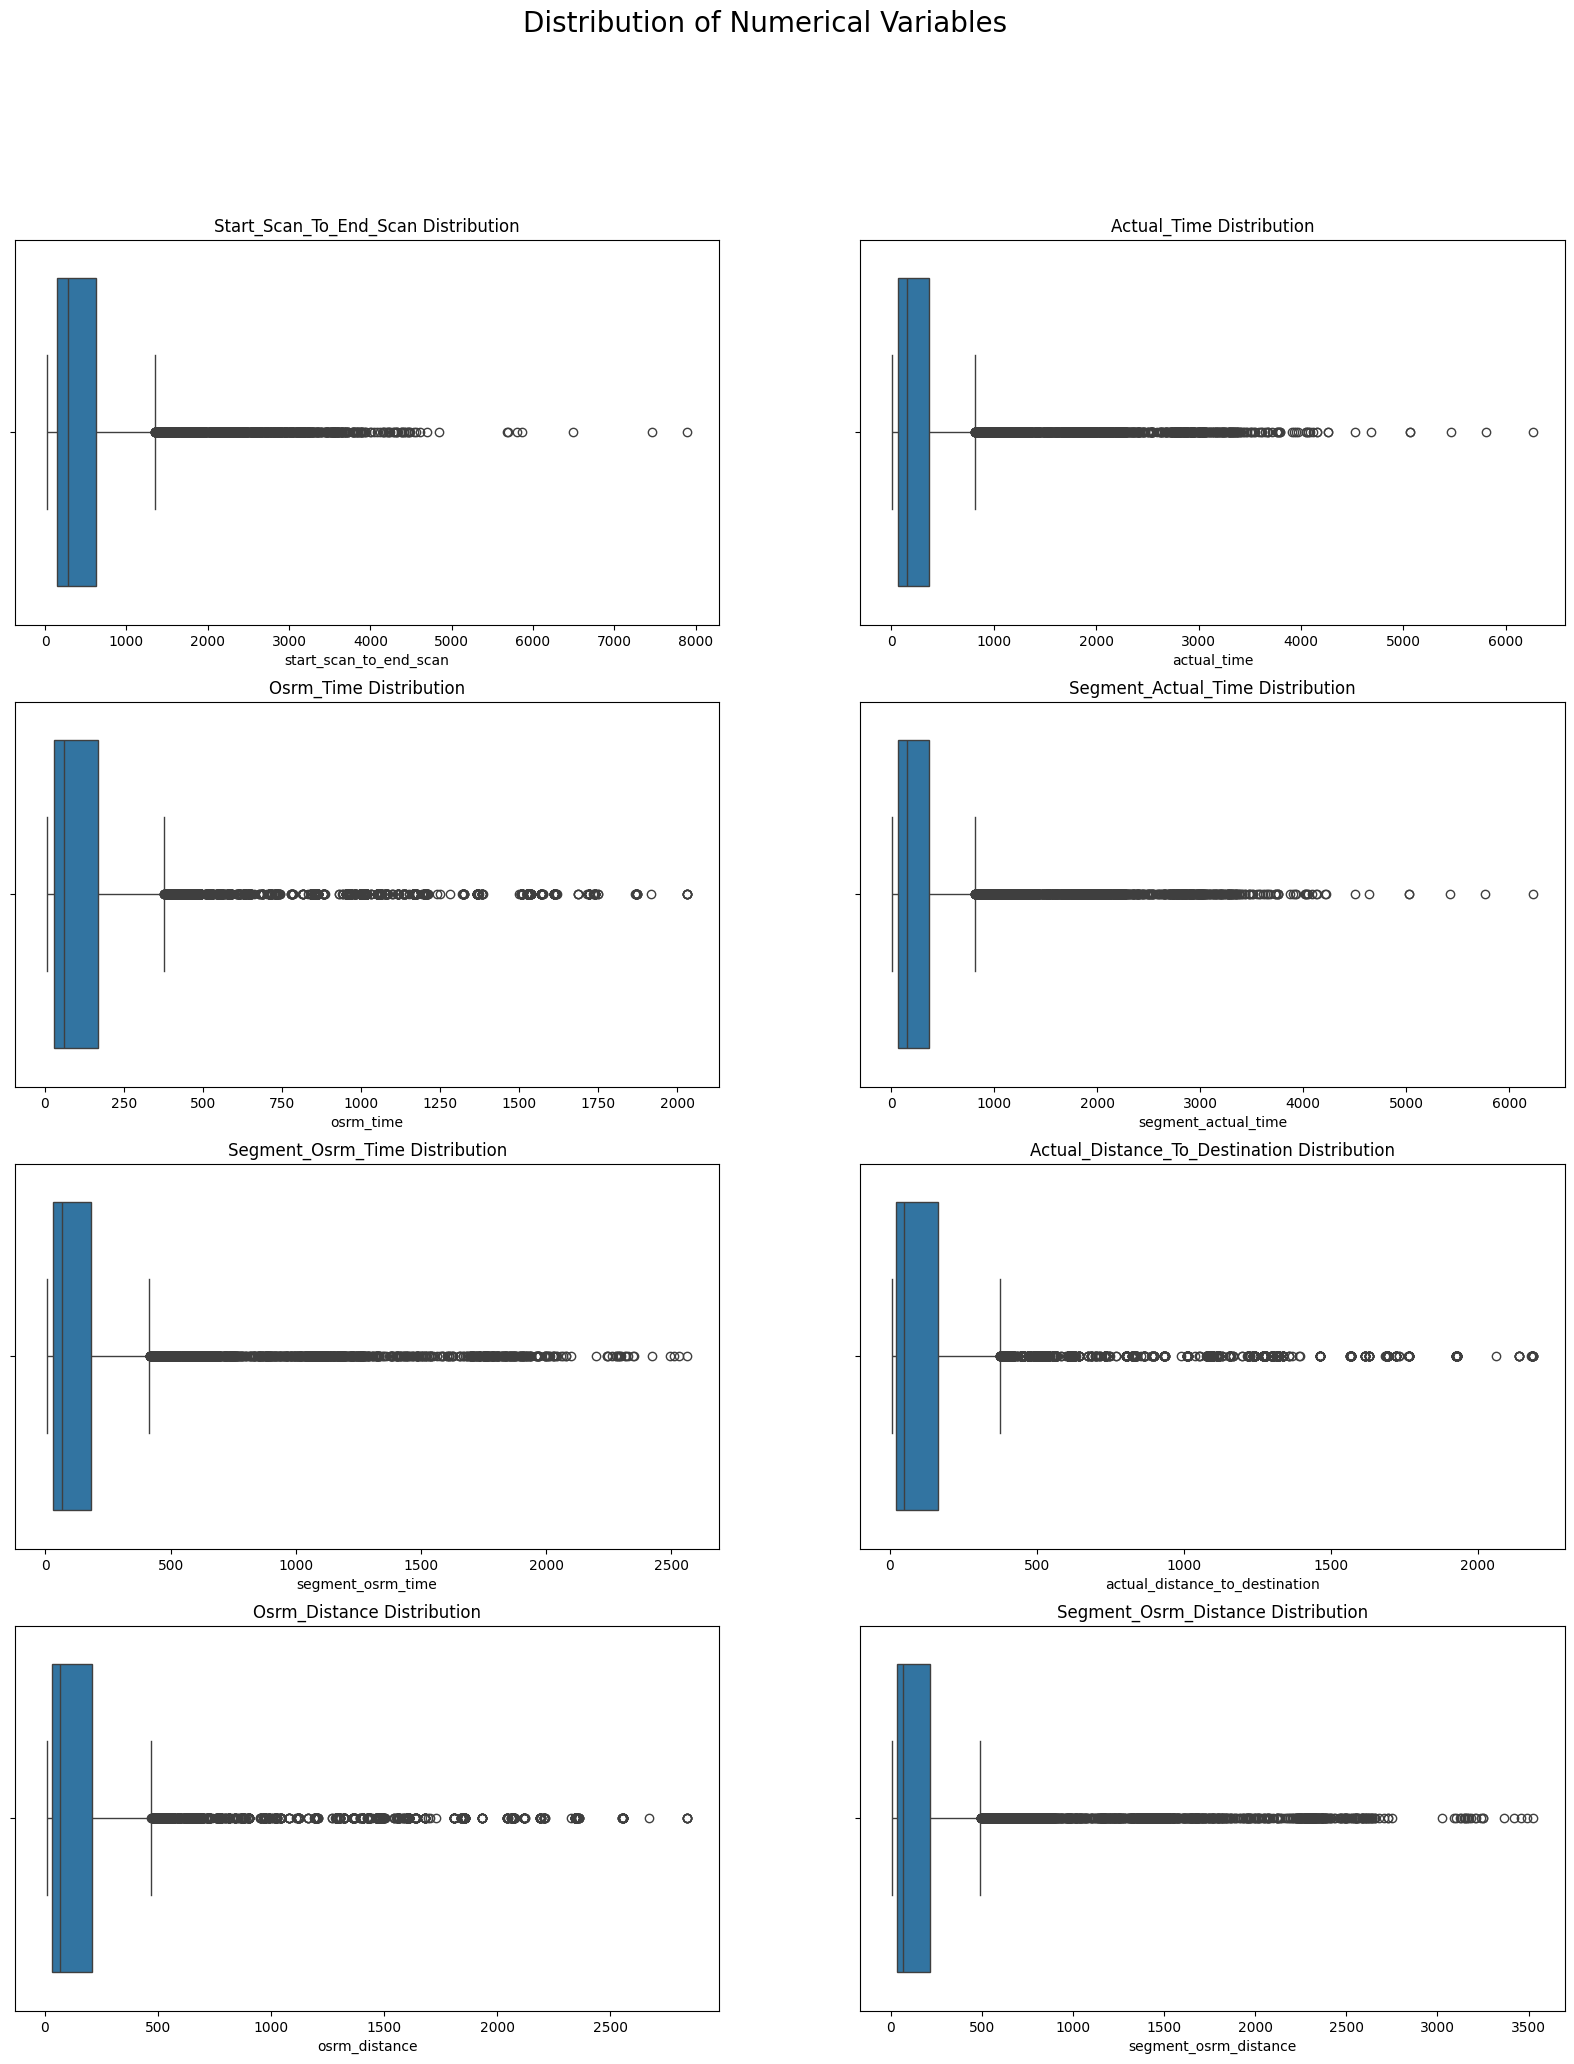

In [184]:
plt.figure(figsize=(20,23)).suptitle("Distribution of Numerical Variables", fontsize=20)
for j,i in enumerate(num_cols):
    plt.subplot(4,2,j+1)
    plt.title(f'{i.title()} Distribution')
    sns.boxplot(data, x=i)
plt.show()

*>**Insight:** There are many outliers in the data*

**Try Establishing A Relationship Between The Dependent And Independent Variables.**

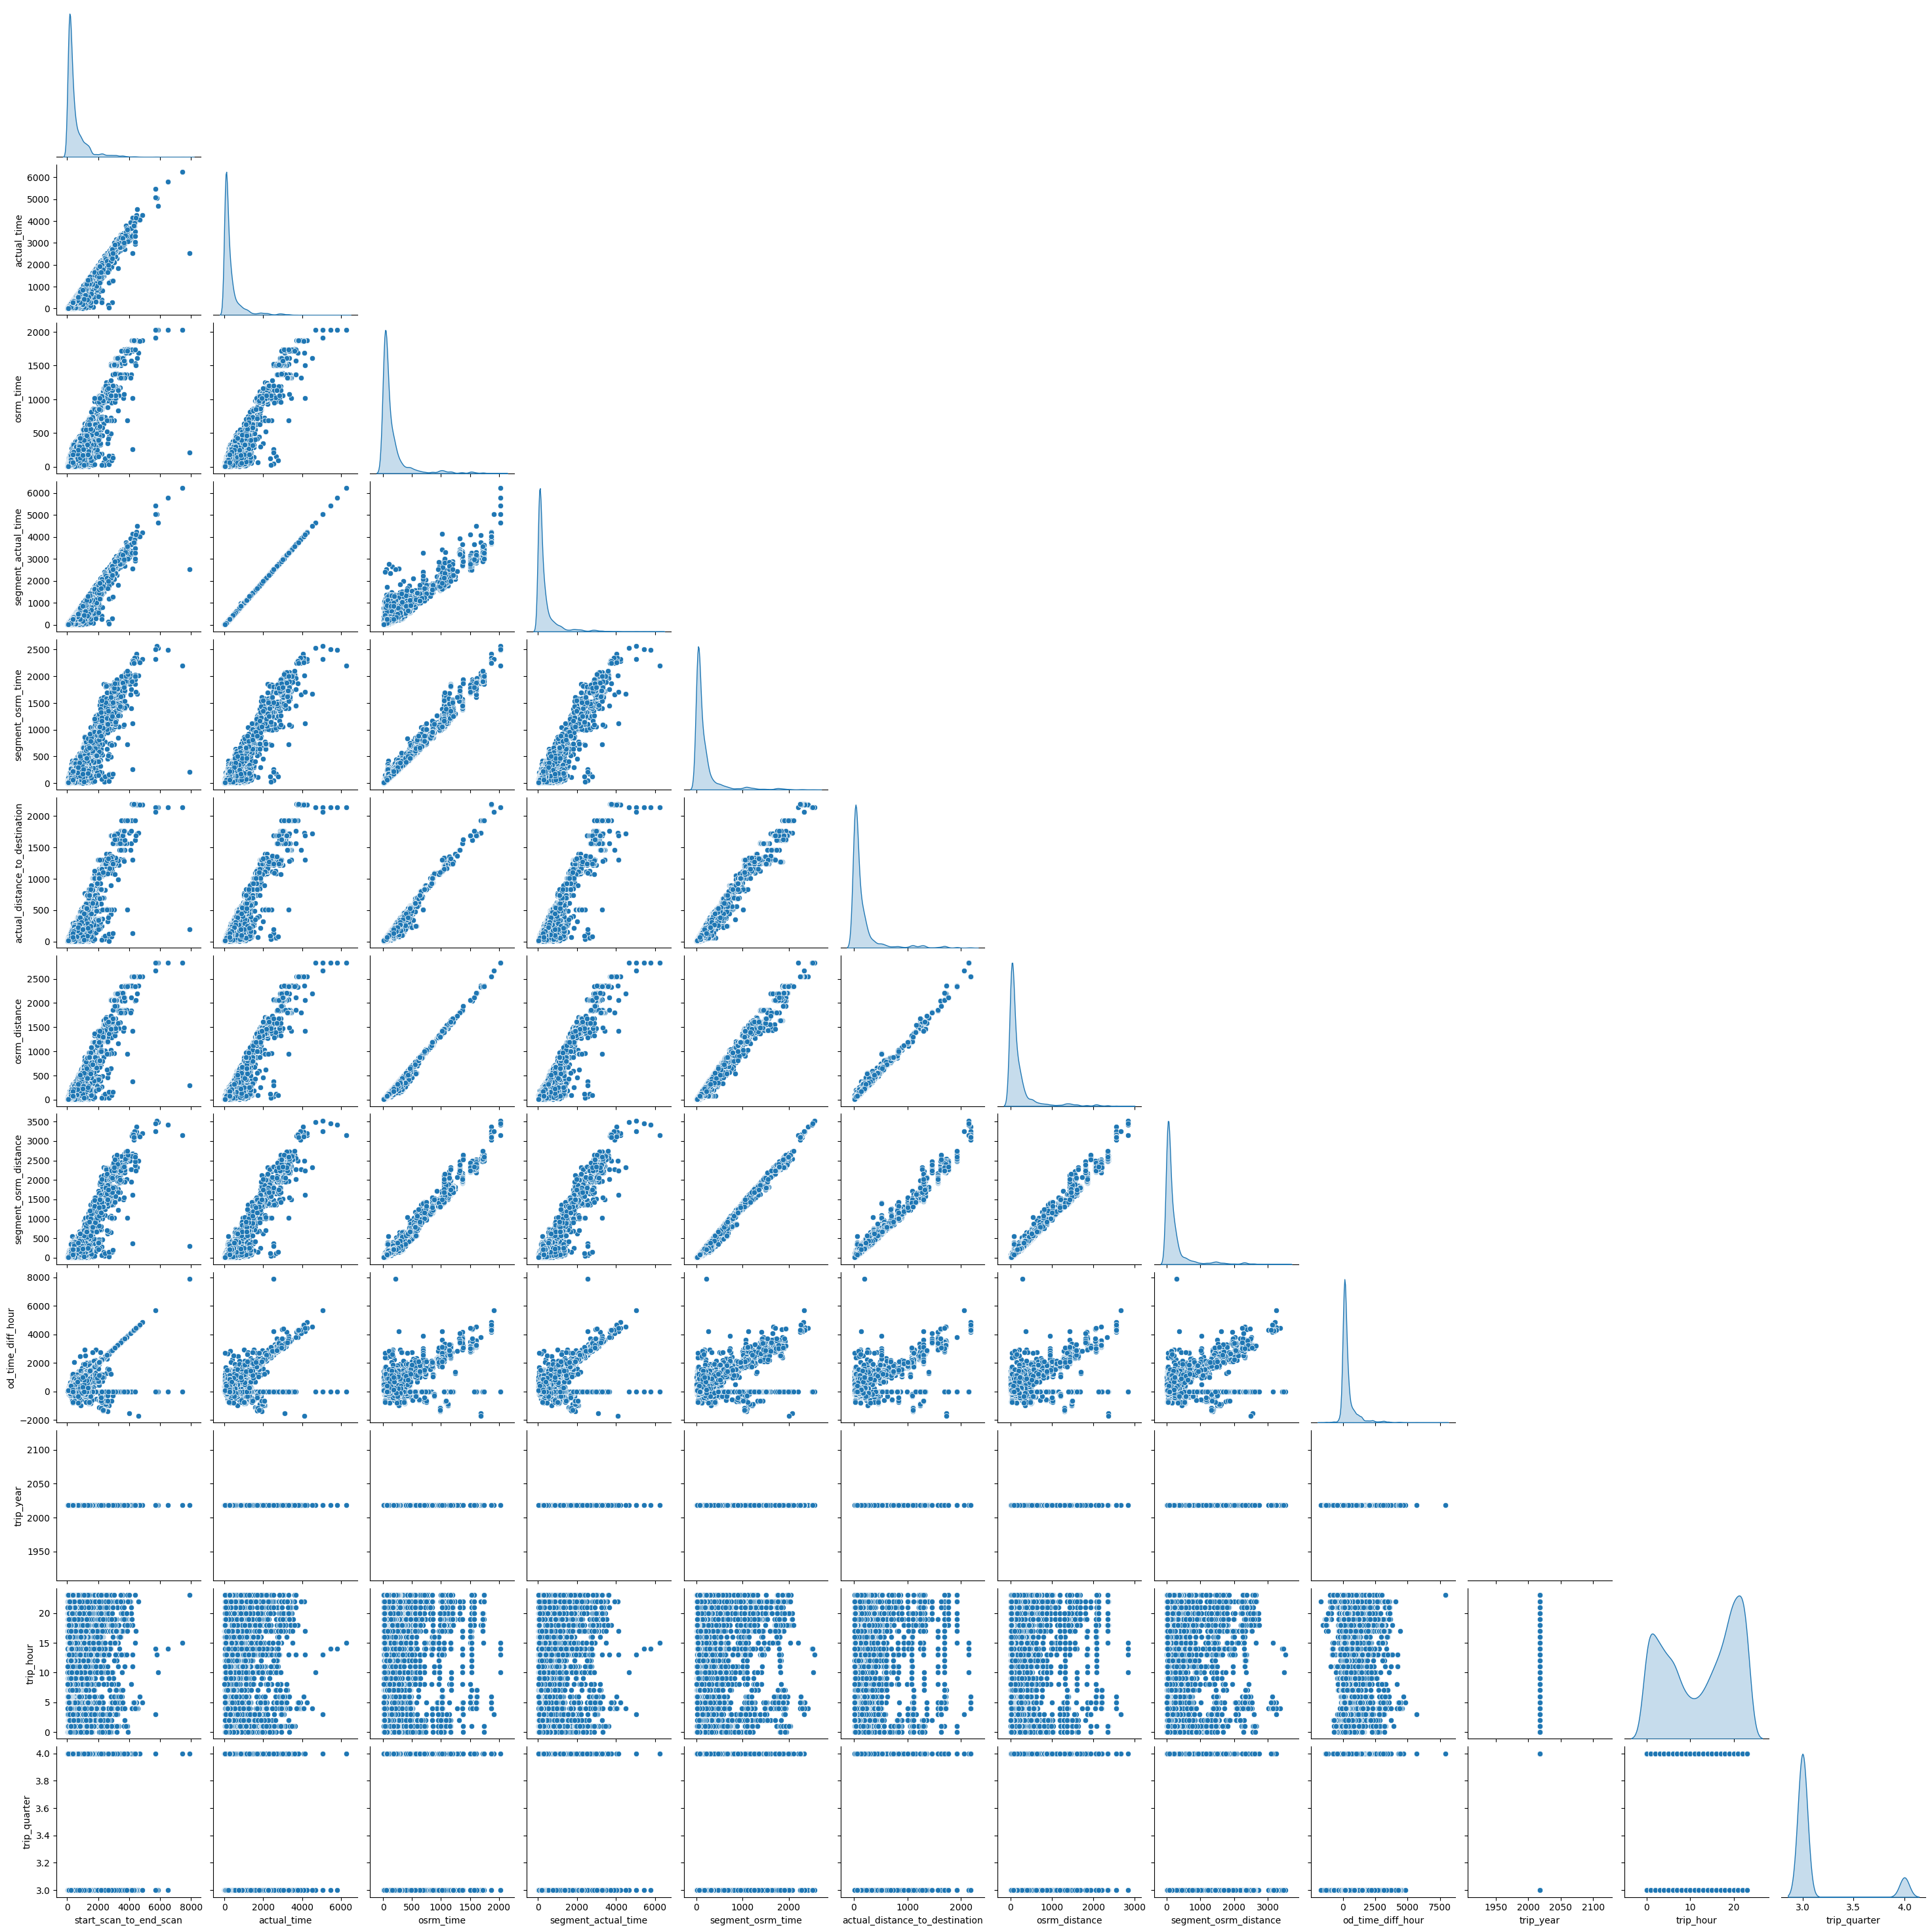

In [185]:
sns.pairplot(data= data, corner=True, diag_kind="kde")
plt.show()

In [186]:
data[num_cols].corr(numeric_only=True)

,start_scan_to_end_scan,actual_time,osrm_time,segment_actual_time,segment_osrm_time,actual_distance_to_destination,osrm_distance,segment_osrm_distance
start_scan_to_end_scan,1.000000,0.961612,0.927471,0.961634,0.919429,0.919159,0.925205,0.920191
actual_time,0.961612,1.000000,0.958781,0.999989,0.954044,0.953920,0.959398,0.957151
osrm_time,0.927471,0.958781,1.000000,0.957955,0.993263,0.993568,0.997588,0.991624
segment_actual_time,0.961634,0.999989,0.957955,1.000000,0.953214,0.952987,0.958540,0.956293
segment_osrm_time,0.919429,0.954044,0.993263,0.953214,1.000000,0.987542,0.991802,0.996098
actual_distance_to_destination,0.919159,0.953920,0.993568,0.952987,0.987542,1.000000,0.997268,0.993068
osrm_distance,0.925205,0.959398,0.997588,0.958540,0.991802,0.997268,1.000000,0.994712
segment_osrm_distance,0.920191,0.957151,0.991624,0.956293,0.996098,0.993068,0.994712,1.000000


<Axes: >

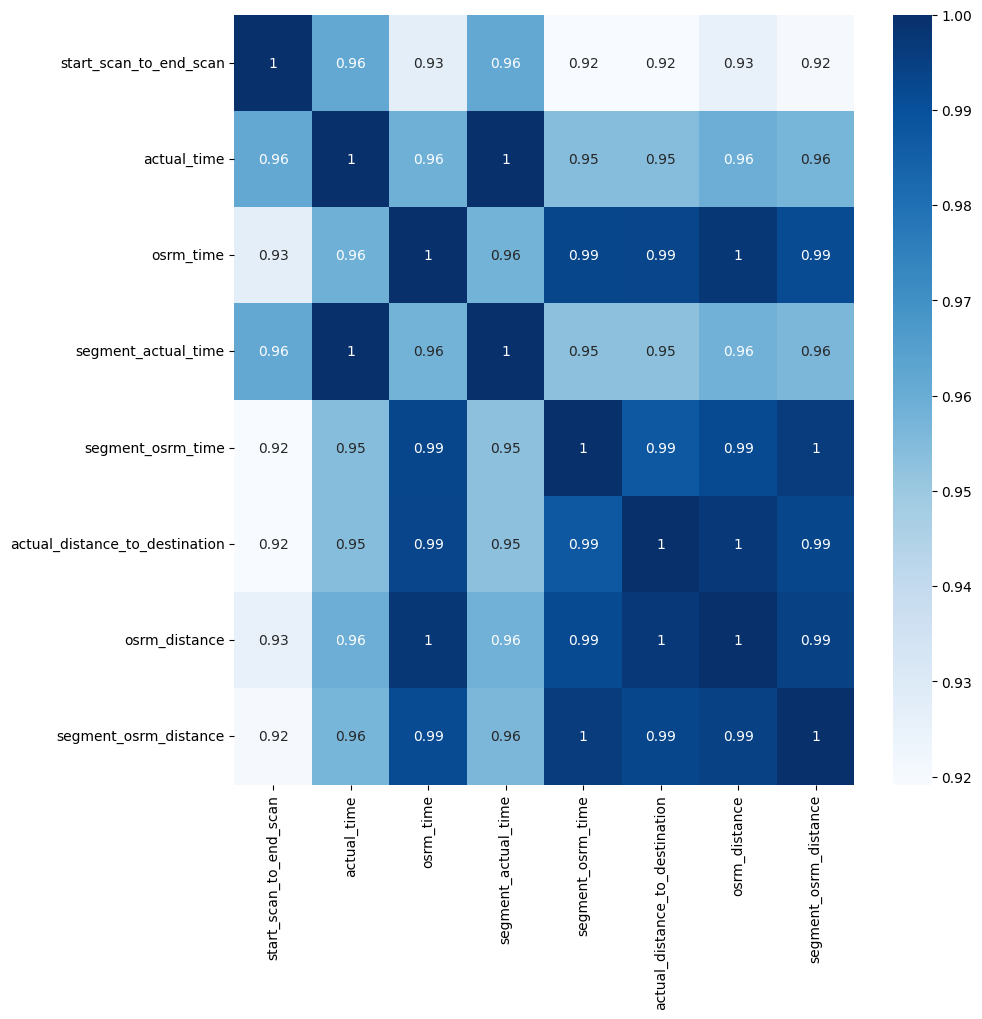

In [187]:
plt.figure(figsize = (10,10))
sns.heatmap(data[num_cols].corr(numeric_only=True), annot = True, cmap= "Blues")

*>**Insight:** We can see that almost all num cols have a correlation*

**Bivariate Analysis**

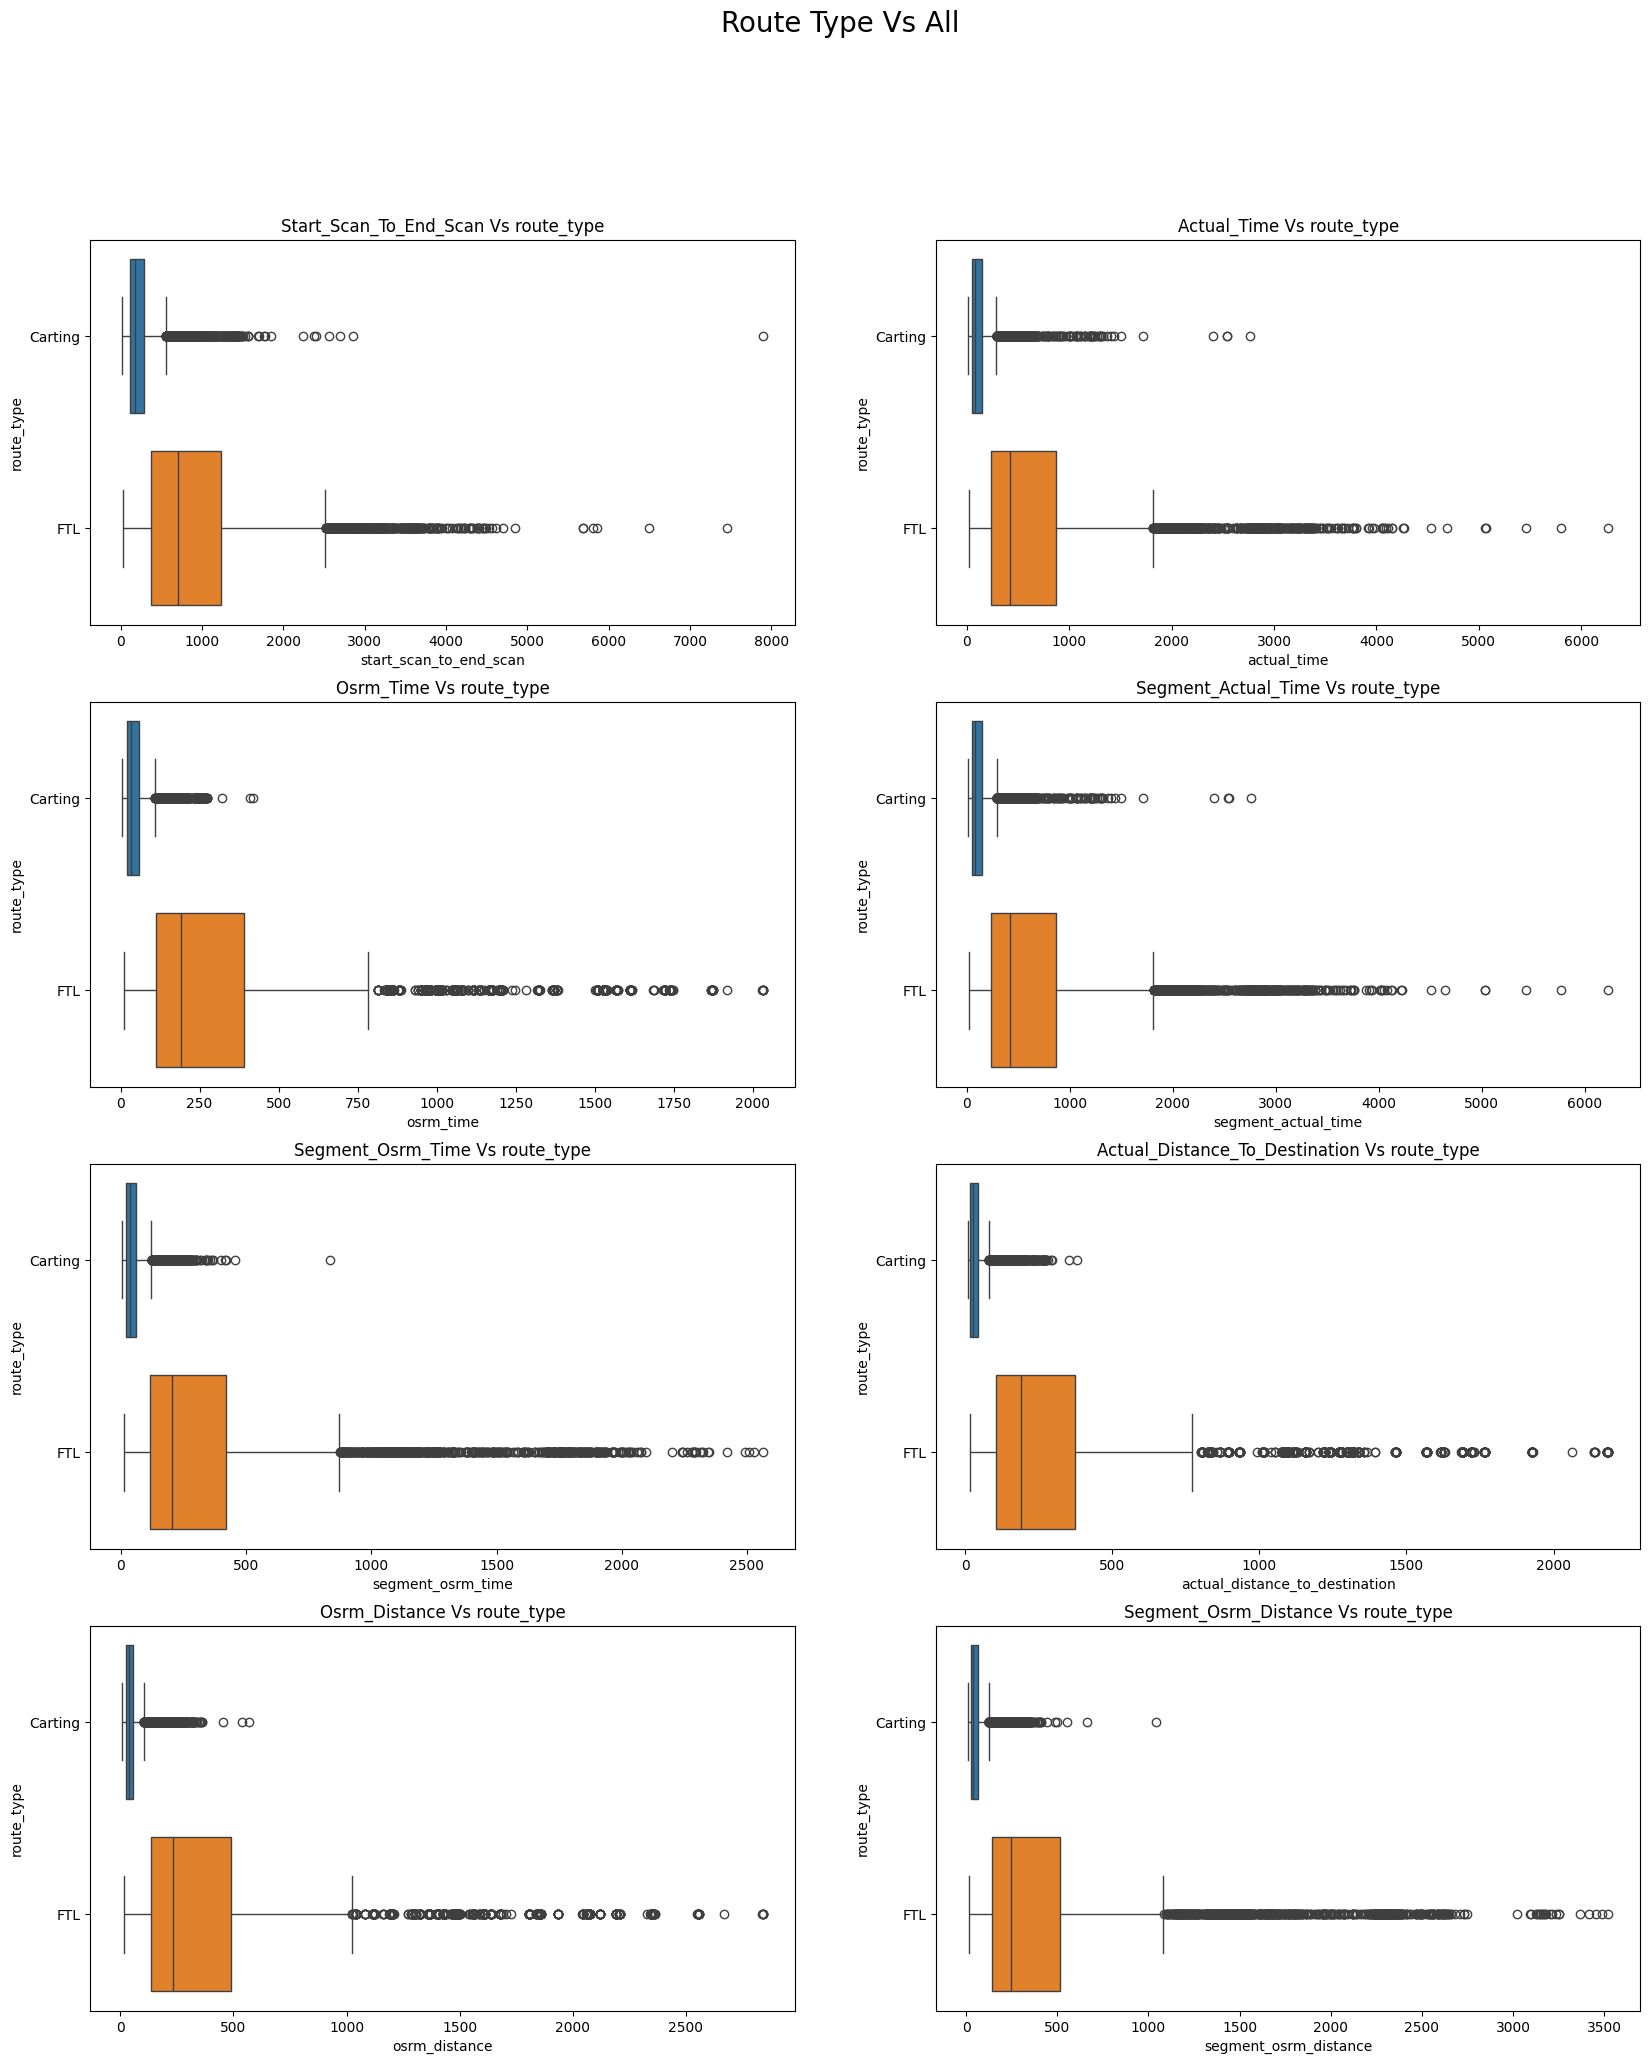

In [188]:
plt.figure(figsize=(20,23)).suptitle("Route Type Vs All", fontsize=20)
for j,i in enumerate(num_cols):
    plt.subplot(4,2,j+1)
    plt.title(f'{i.title()} Vs route_type')
    sns.boxplot(data, y= 'route_type', x= i, hue= 'route_type')
plt.show()

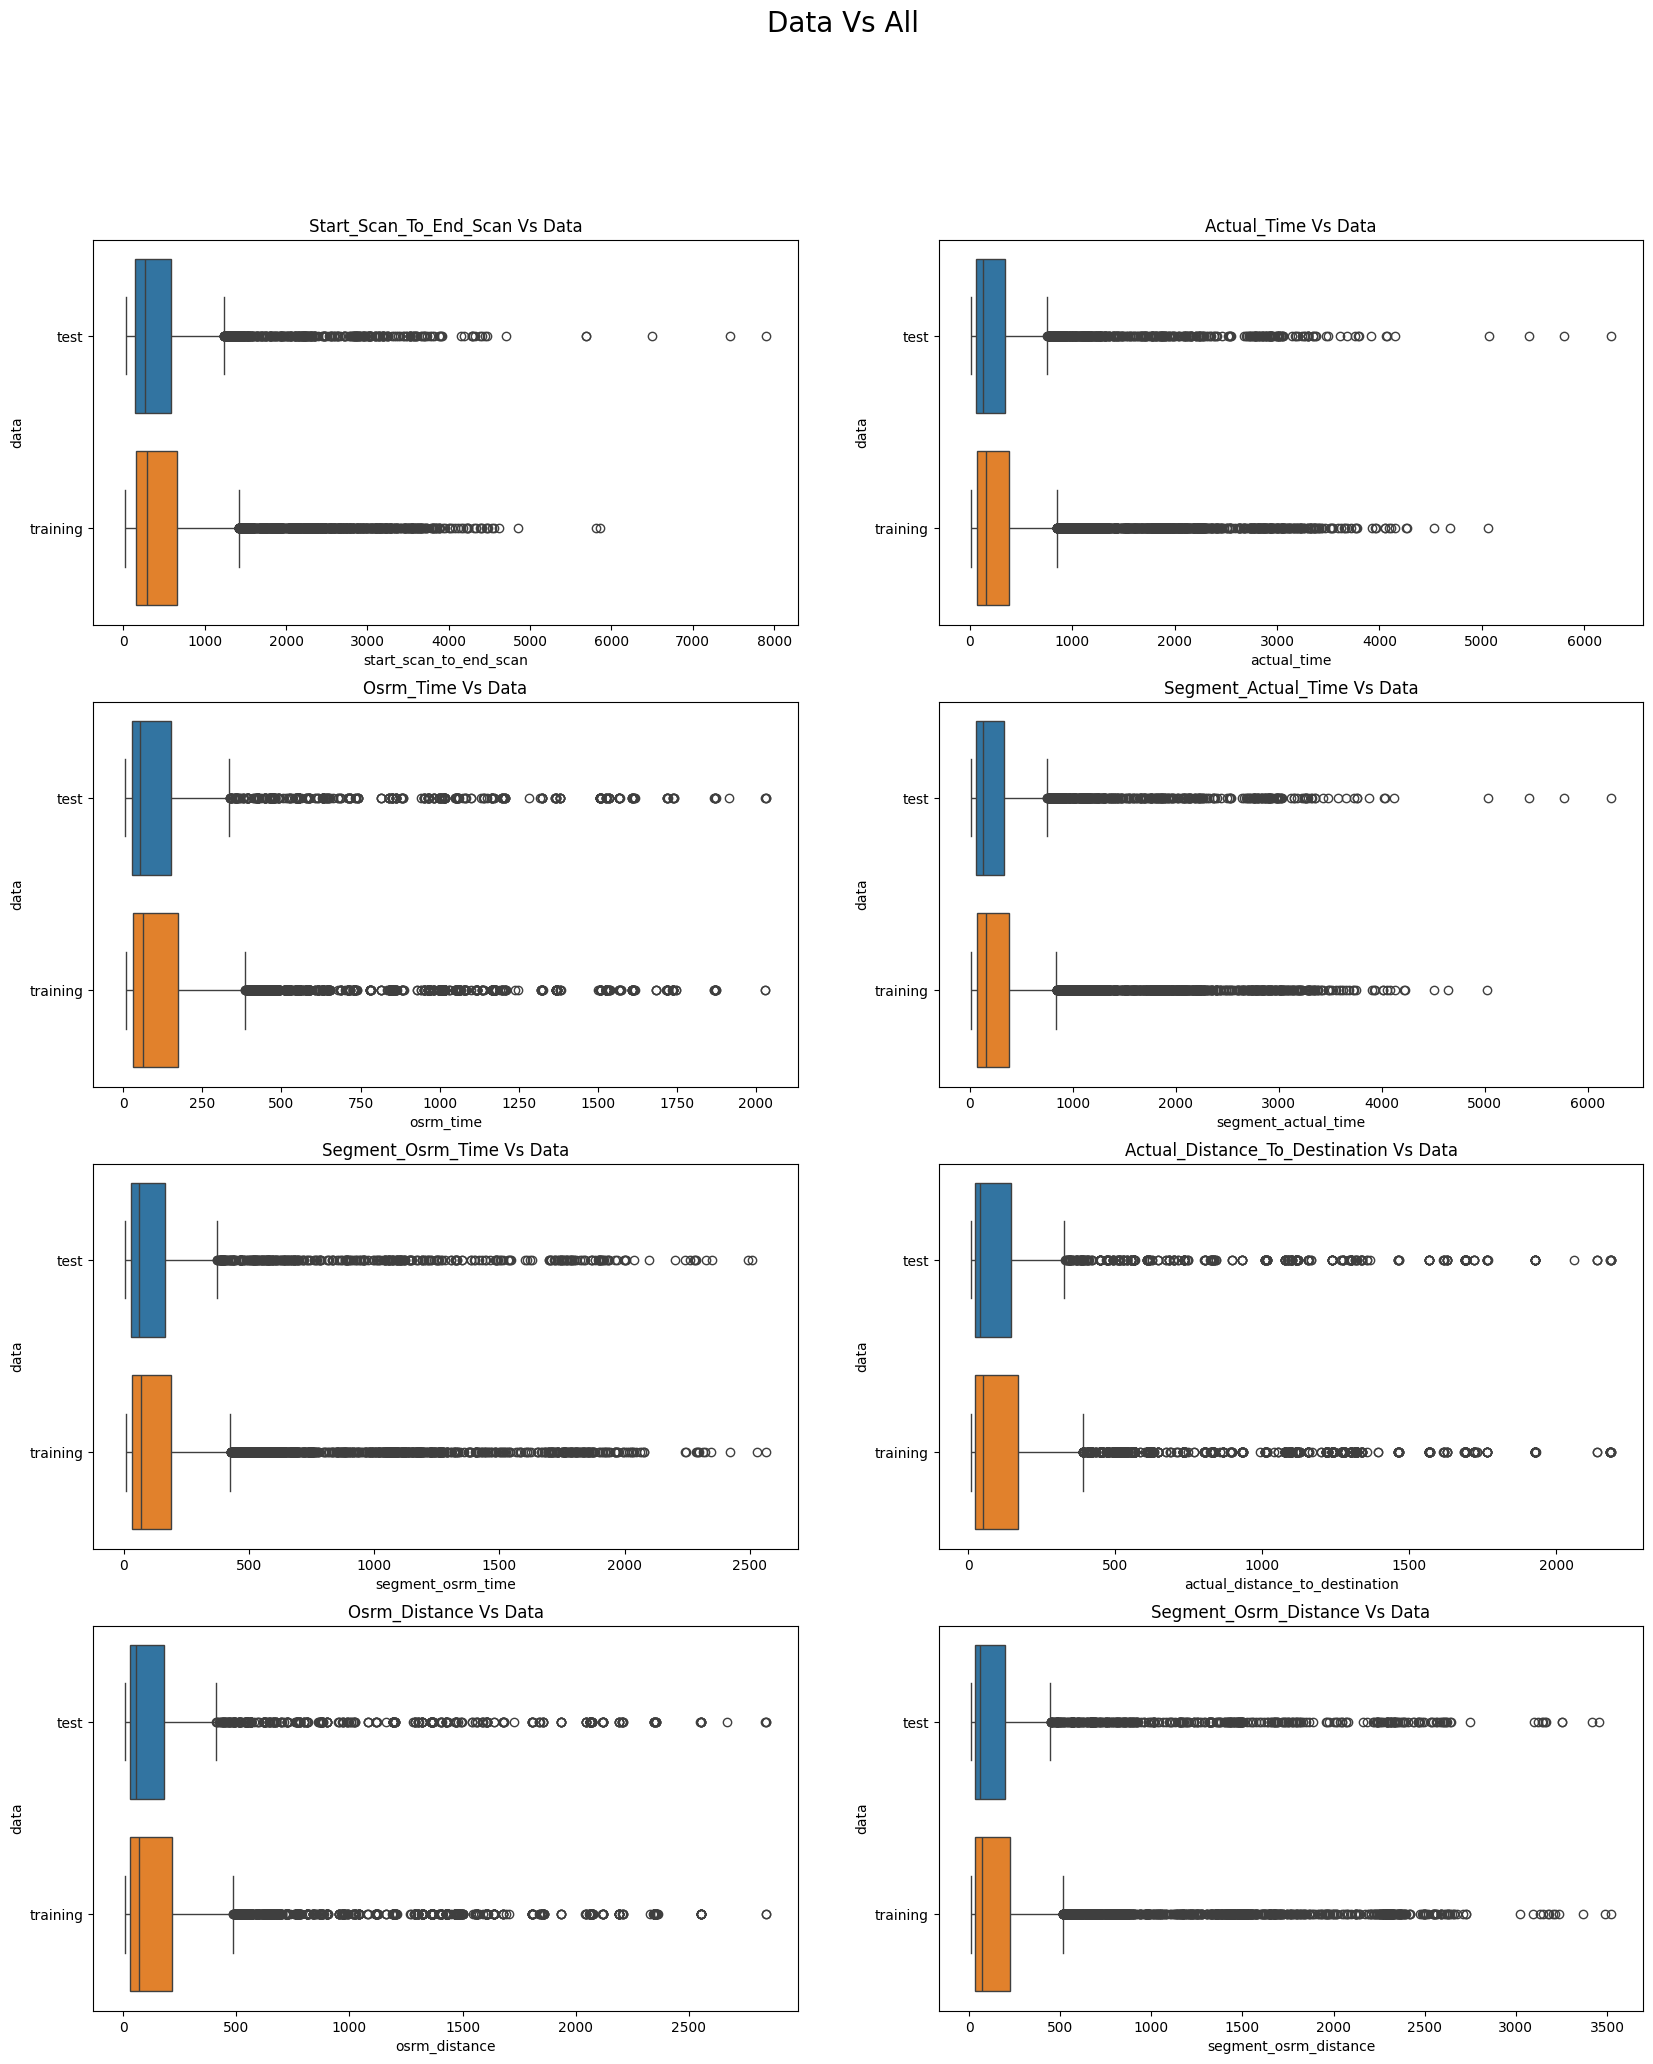

In [189]:
plt.figure(figsize=(20,23)).suptitle("Data Vs All", fontsize=20)
for j,i in enumerate(num_cols):
    plt.subplot(4,2,j+1)
    plt.title(f'{i.title()} Vs Data')
    sns.boxplot(data, y= 'data', x= i, hue= 'data')
plt.show()

#**Outlier Detection & Treatment**

In [190]:
for i in num_cols:
    print(i.upper())
    q1=data[i].quantile(0.25)
    q3=data[i].quantile(0.75)
    IQR=q3-q1
    print(f'Q1: {q1}, Q2: {q3}, IQR: {IQR}')
    outliers = data[((data[i]<(q1-1.5*IQR)) | (data[i]>(q3+1.5*IQR)))]
    print("No Of Outliers: ", len(outliers))
    print("Percent Of Outliers : ", len(outliers)/len(data)*100)
    print('-'*50)
    print()

START_SCAN_TO_END_SCAN
Q1: 149.0, Q2: 632.0, IQR: 483.0
No Of Outliers:  1282
Percent Of Outliers :  8.669777507269899
--------------------------------------------------

ACTUAL_TIME
Q1: 67.0, Q2: 367.0, IQR: 300.0
No Of Outliers:  1646
Percent Of Outliers :  11.13139920200176
--------------------------------------------------

OSRM_TIME
Q1: 29.0, Q2: 168.0, IQR: 139.0
No Of Outliers:  1506
Percent Of Outliers :  10.184621627104889
--------------------------------------------------

SEGMENT_ACTUAL_TIME
Q1: 66.0, Q2: 364.0, IQR: 298.0
No Of Outliers:  1644
Percent Of Outliers :  11.11787380807466
--------------------------------------------------

SEGMENT_OSRM_TIME
Q1: 30.0, Q2: 184.0, IQR: 154.0
No Of Outliers:  1485
Percent Of Outliers :  10.042604990870359
--------------------------------------------------

ACTUAL_DISTANCE_TO_DESTINATION
Q1: 22.777098943155323, Q2: 163.5912581579725, IQR: 140.81415921481718
No Of Outliers:  1452
Percent Of Outliers :  9.81943599107324
---------------

**We will will dropping the outliers as the avg outliers percentage is around only 7%**

In [191]:
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)

IQR = Q3 - Q1
data = data[~((data[num_cols]<(q1-1.5*IQR)) | (data[num_cols]>(q3+1.5*IQR))).any(axis=1)]
data = data.reset_index(drop=True)

In [192]:
data.shape

(12209, 33)

**Shape of Data after droping outliers is 12209 rows, 33 columns.**

**Top 10 Deliveries from Source State**

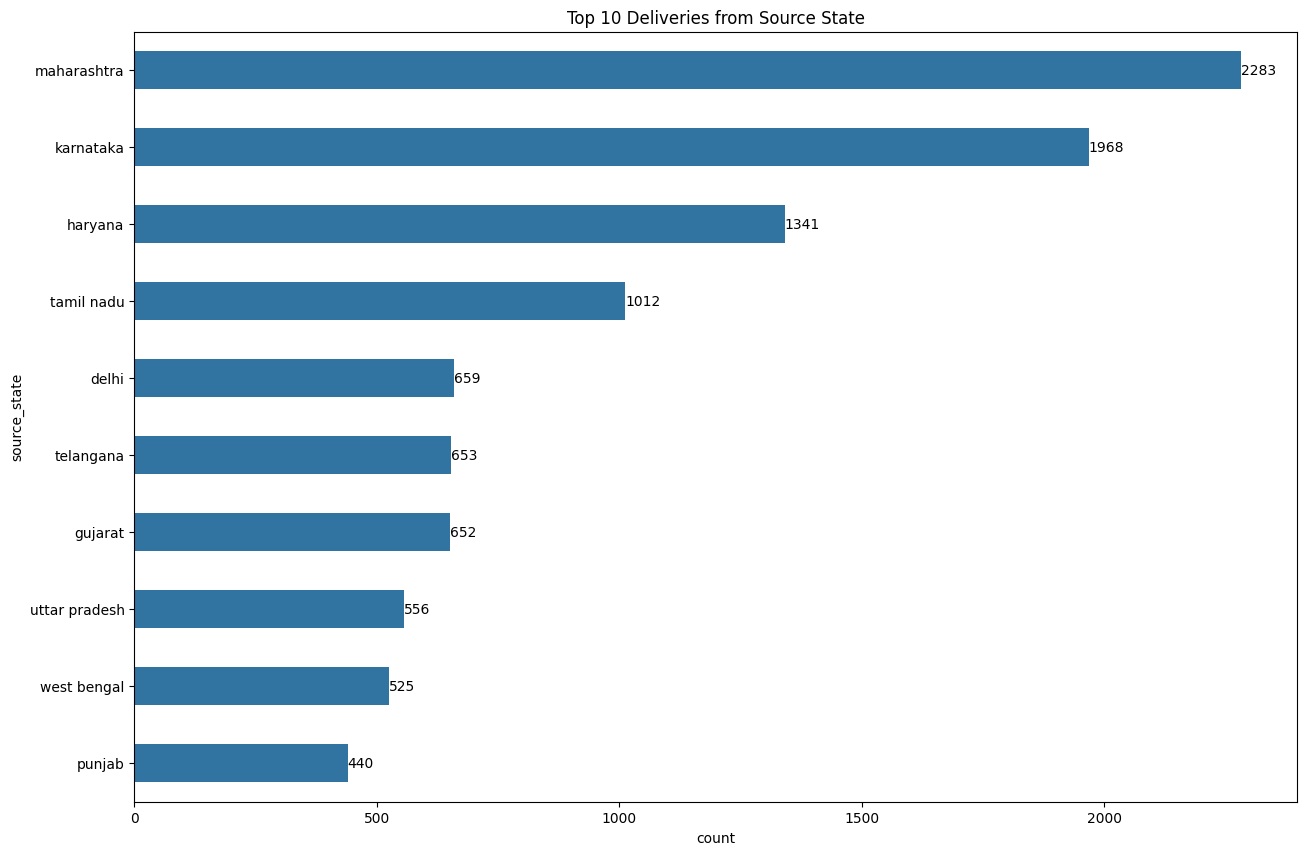

In [193]:
plt.figure(figsize=(15,10))
plt.title('Top 10 Deliveries from Source State')
ax= sns.barplot(data= data['source_state'].value_counts().head(10).reset_index(), y= 'source_state', x= 'count', width=0.5)
ax.bar_label(ax.containers[0])
plt.show()

**Top 10 Deliveries from Destination State**

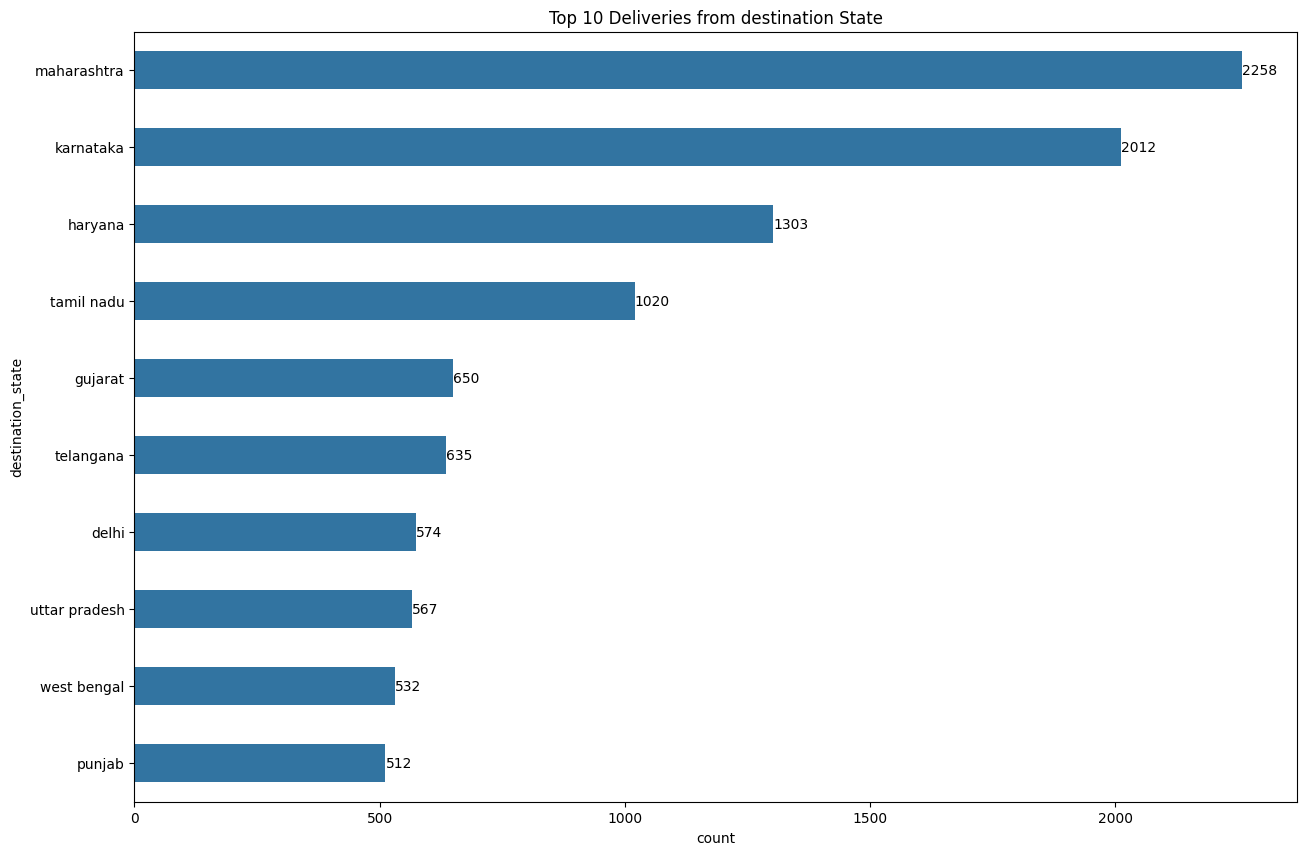

In [194]:
plt.figure(figsize=(15,10))
plt.title('Top 10 Deliveries from destination State')
ax= sns.barplot(data= data['destination_state'].value_counts().head(10).reset_index(), y= 'destination_state', x= 'count', width=0.5)
ax.bar_label(ax.containers[0])
plt.show()

**Top 10 Deliveries from source_city**

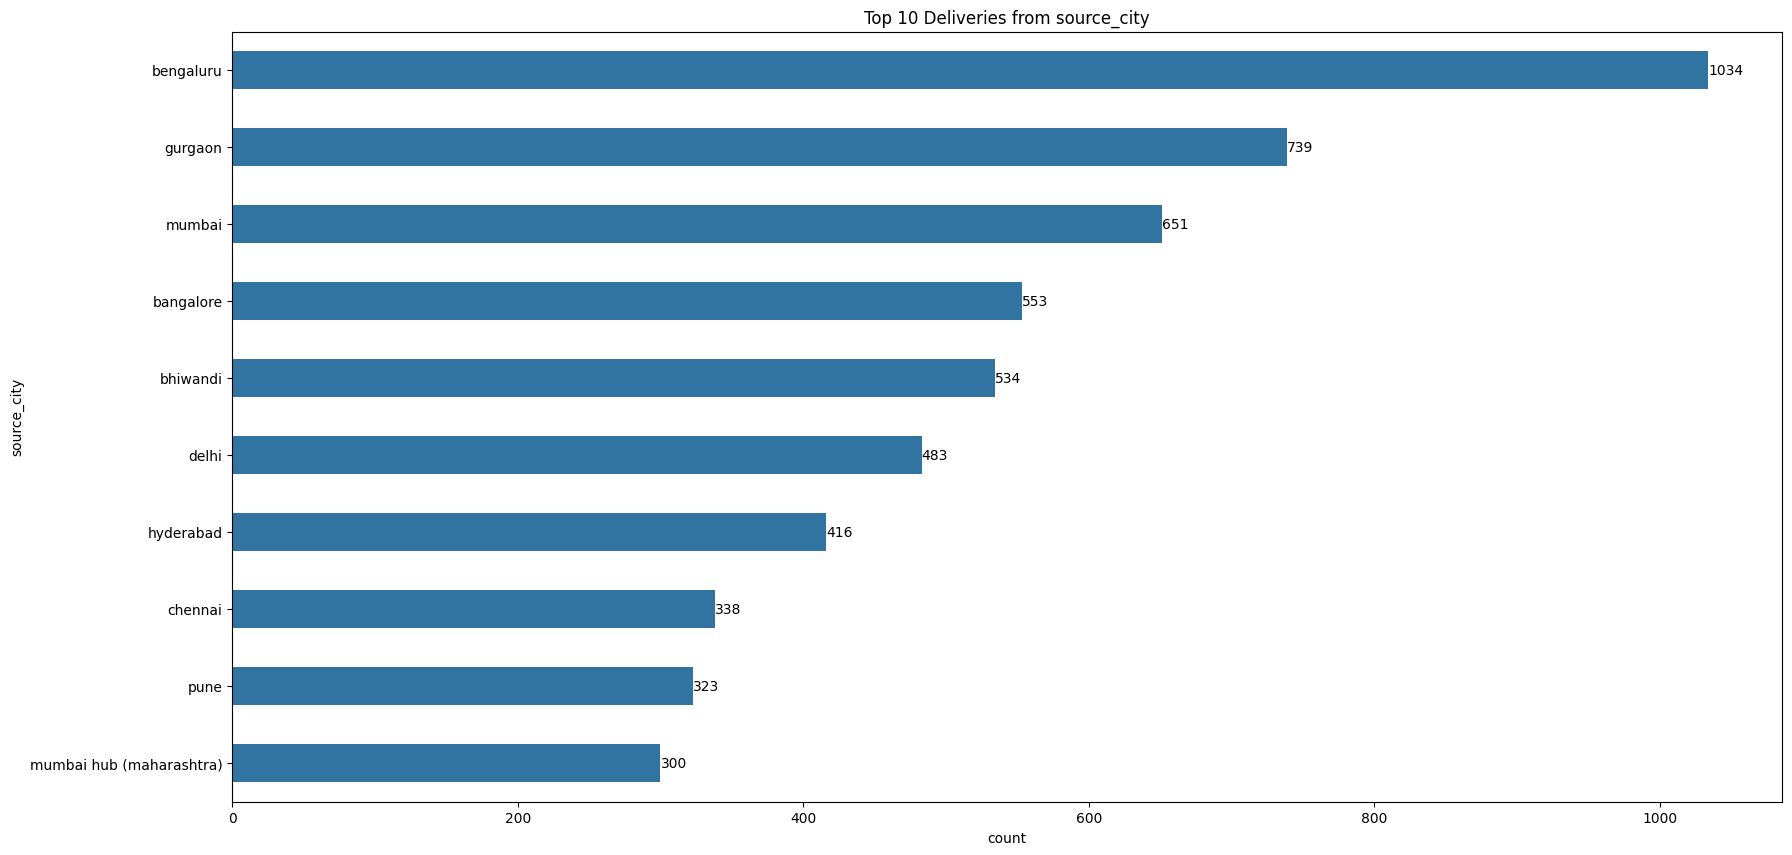

In [195]:
plt.figure(figsize=(20,10))
plt.title('Top 10 Deliveries from source_city')
ax= sns.barplot(data= data['source_city'].value_counts().head(10).reset_index(), y= 'source_city', x= 'count', width=0.5)
ax.bar_label(ax.containers[0])
plt.show()

**Top 10 Deliveries from Destination city**

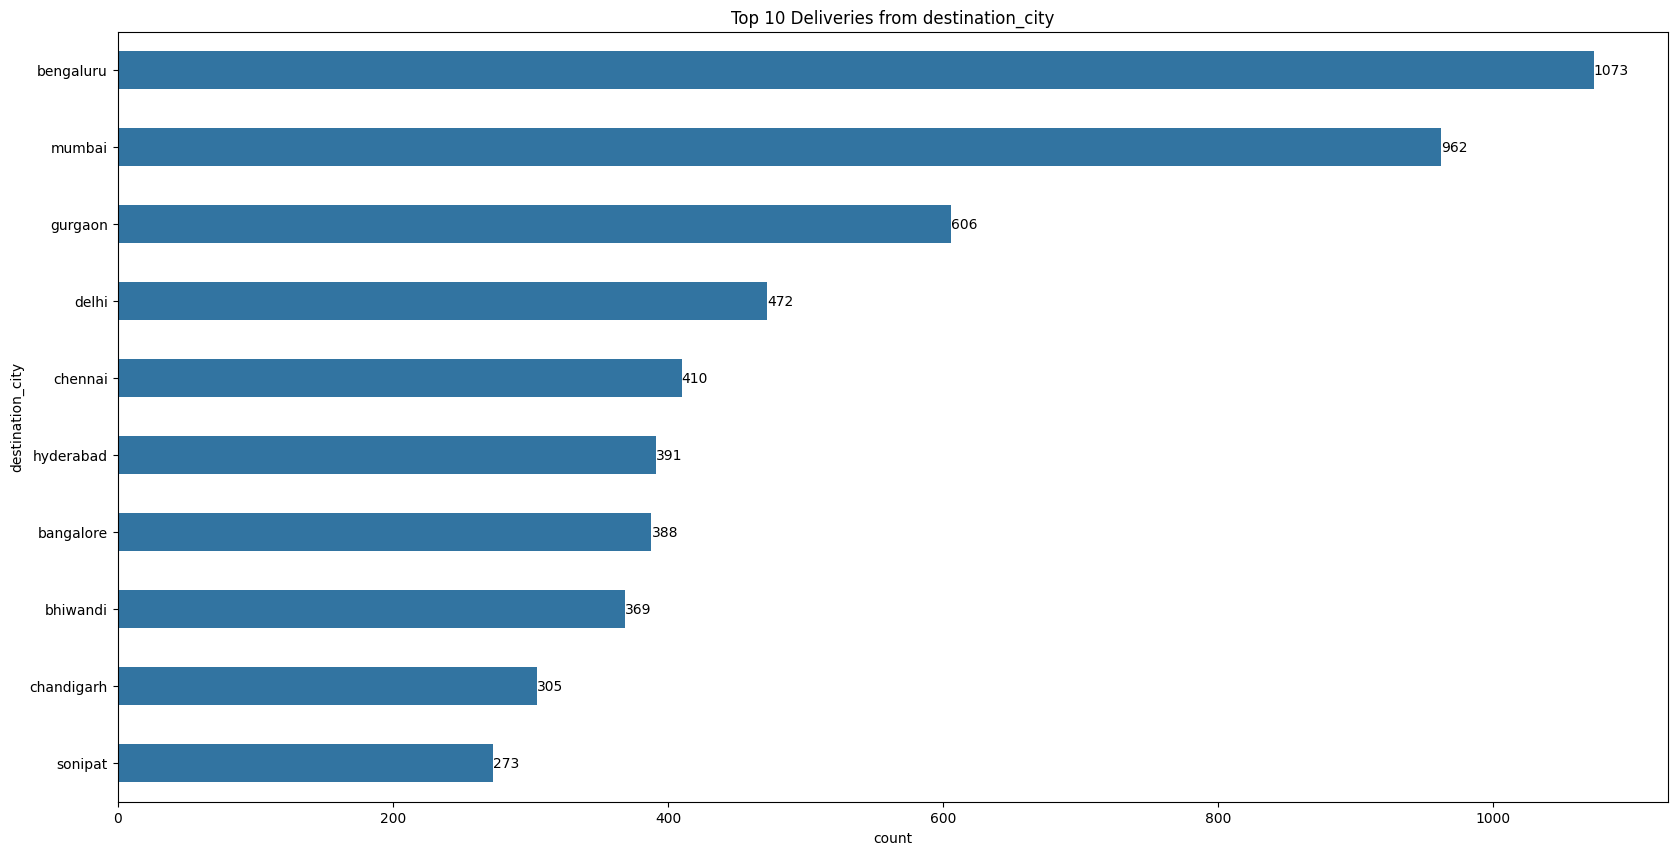

In [196]:
plt.figure(figsize=(20,10))
plt.title('Top 10 Deliveries from destination_city')
ax= sns.barplot(data= data['destination_city'].value_counts().head(10).reset_index(), y= 'destination_city', x= 'count', width=0.5)
ax.bar_label(ax.containers[0])
plt.show()

**Top 10 Deliveries from Source Place**

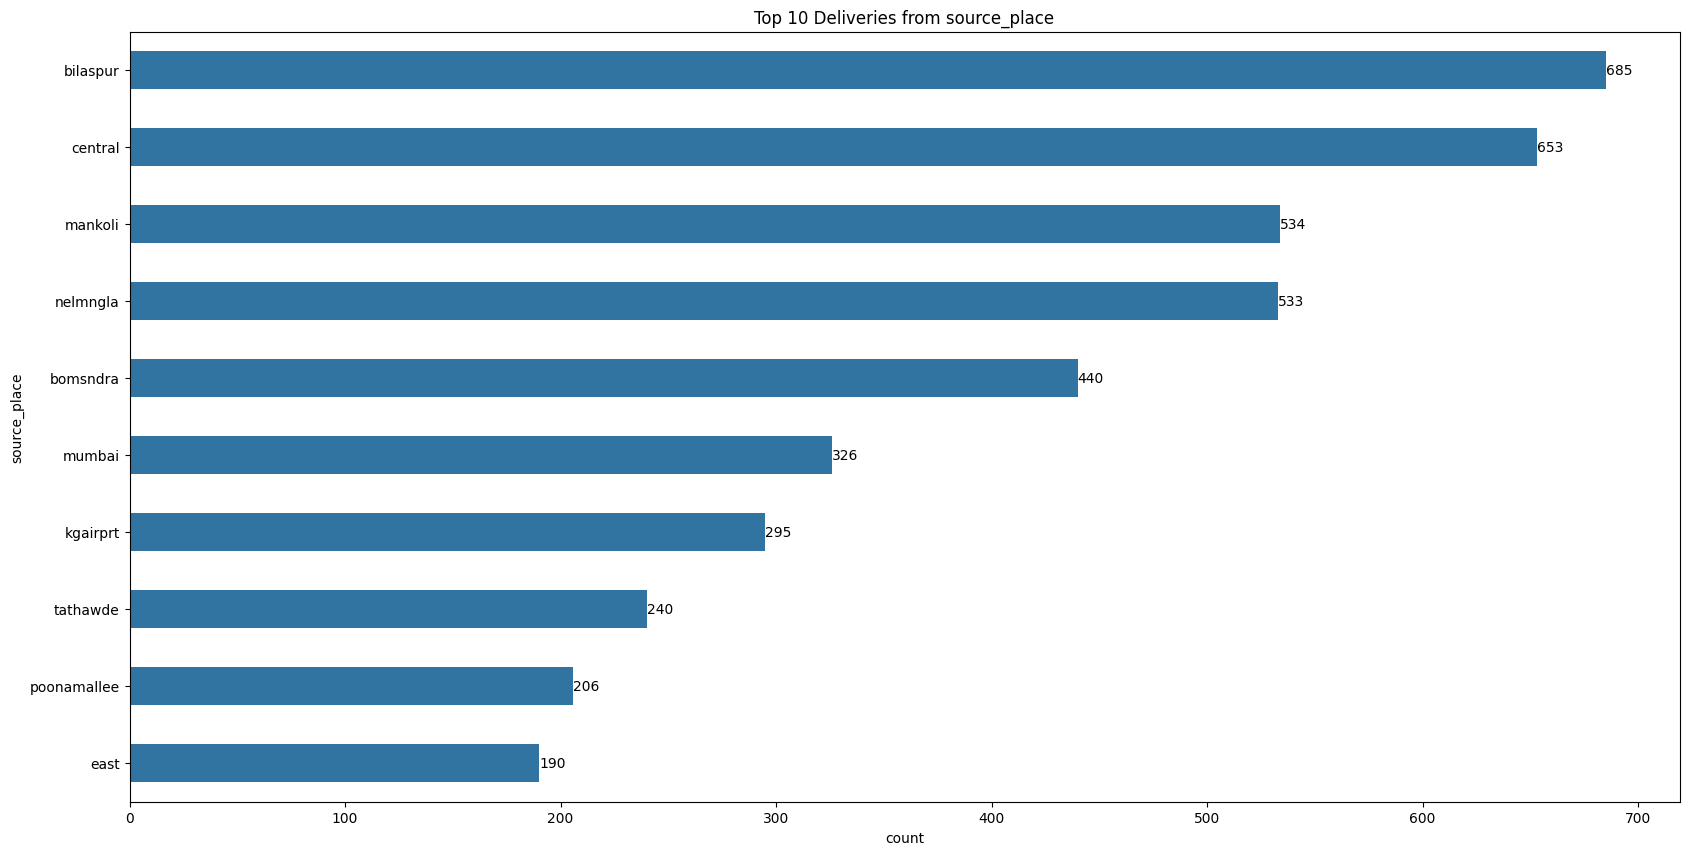

In [197]:
plt.figure(figsize=(20,10))
plt.title('Top 10 Deliveries from source_place')
ax= sns.barplot(data= data['source_place'].value_counts().head(10).reset_index(), y= 'source_place', x= 'count', width=0.5)
ax.bar_label(ax.containers[0])
plt.show()

**Top 10 Deliveries from Destination Place**

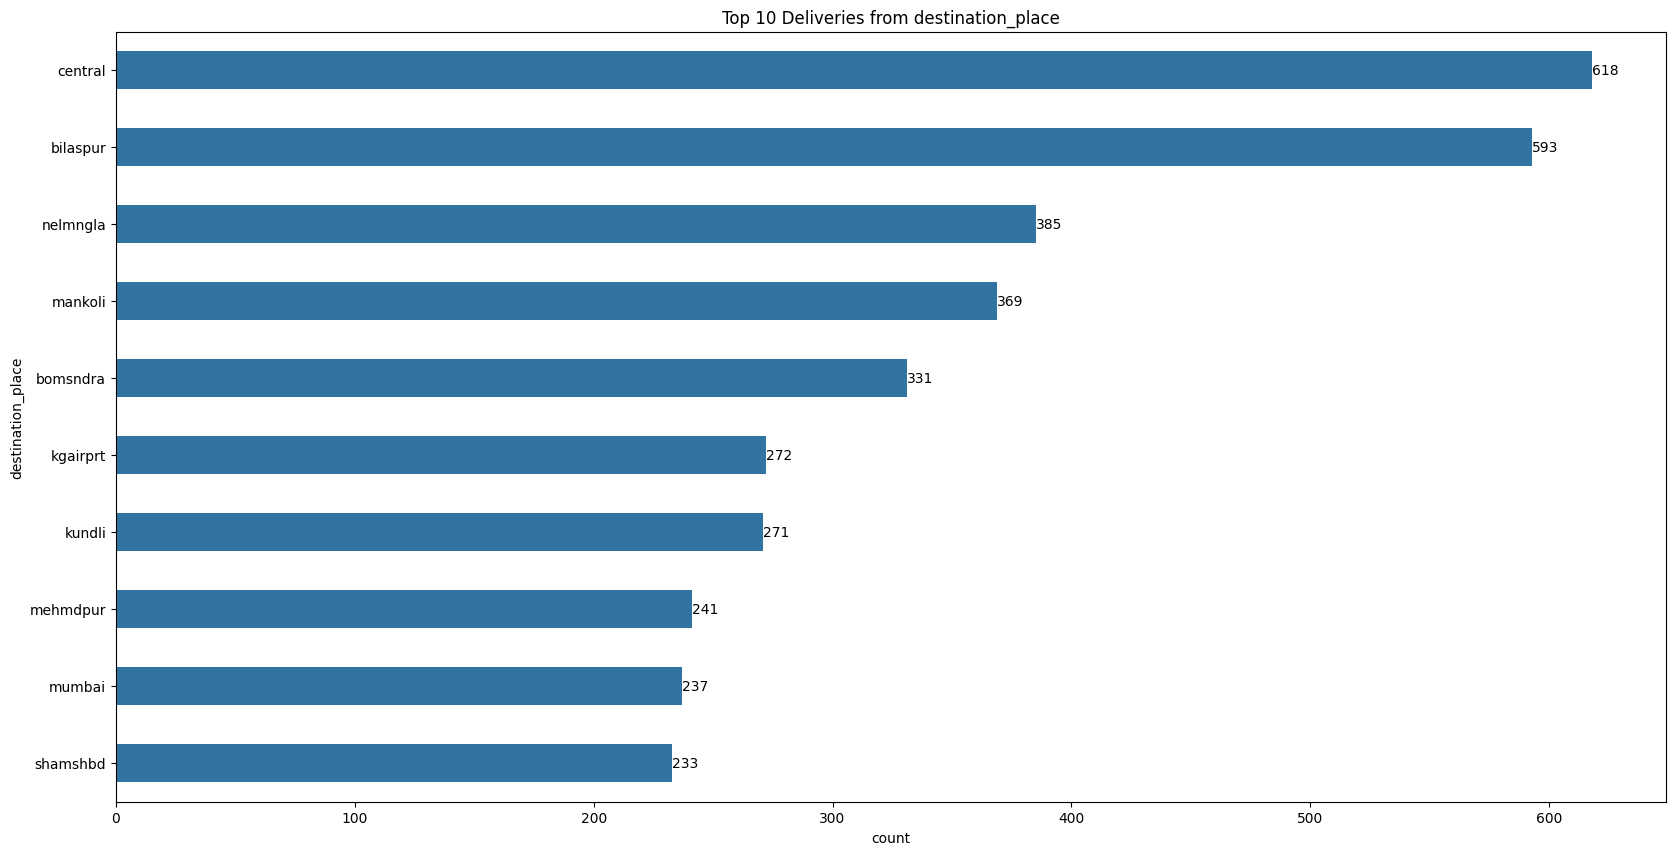

In [198]:
plt.figure(figsize=(20,10))
plt.title('Top 10 Deliveries from destination_place')
ax= sns.barplot(data= data['destination_place'].value_counts().head(10).reset_index(), y= 'destination_place', x= 'count', width=0.5)
ax.bar_label(ax.containers[0])
plt.show()

In [199]:
data['trip_year'].value_counts()

,count
trip_year,
2018,12209


*>**Insight:** We have data of only 2018*

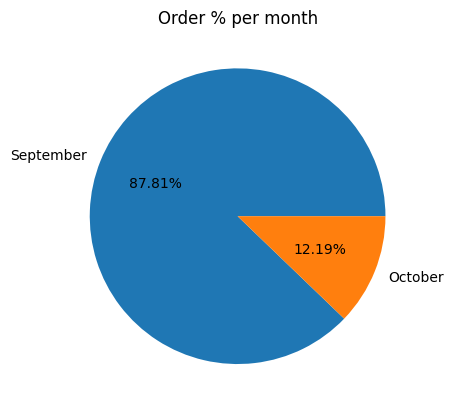

In [200]:
plt.title('Order % per month')
value= data['trip_month'].value_counts()
type_data= data['trip_month'].value_counts().index
plt.pie(value, labels= type_data, autopct= '%2.2f%%')
plt.show()

*>**Insight:** September has 87.81% and October has 12.19%*

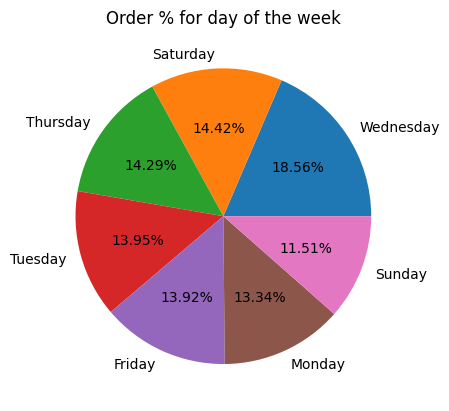

In [201]:
plt.title('Order % for day of the week')
value= data['trip_day'].value_counts()
type_data= data['trip_day'].value_counts().index
plt.pie(value, labels= type_data, autopct= '%2.2f%%')
plt.show()

*>**Insight:** Most % of orders come on Wed, Sat, Thus followed by Tue, Fri, Mon*

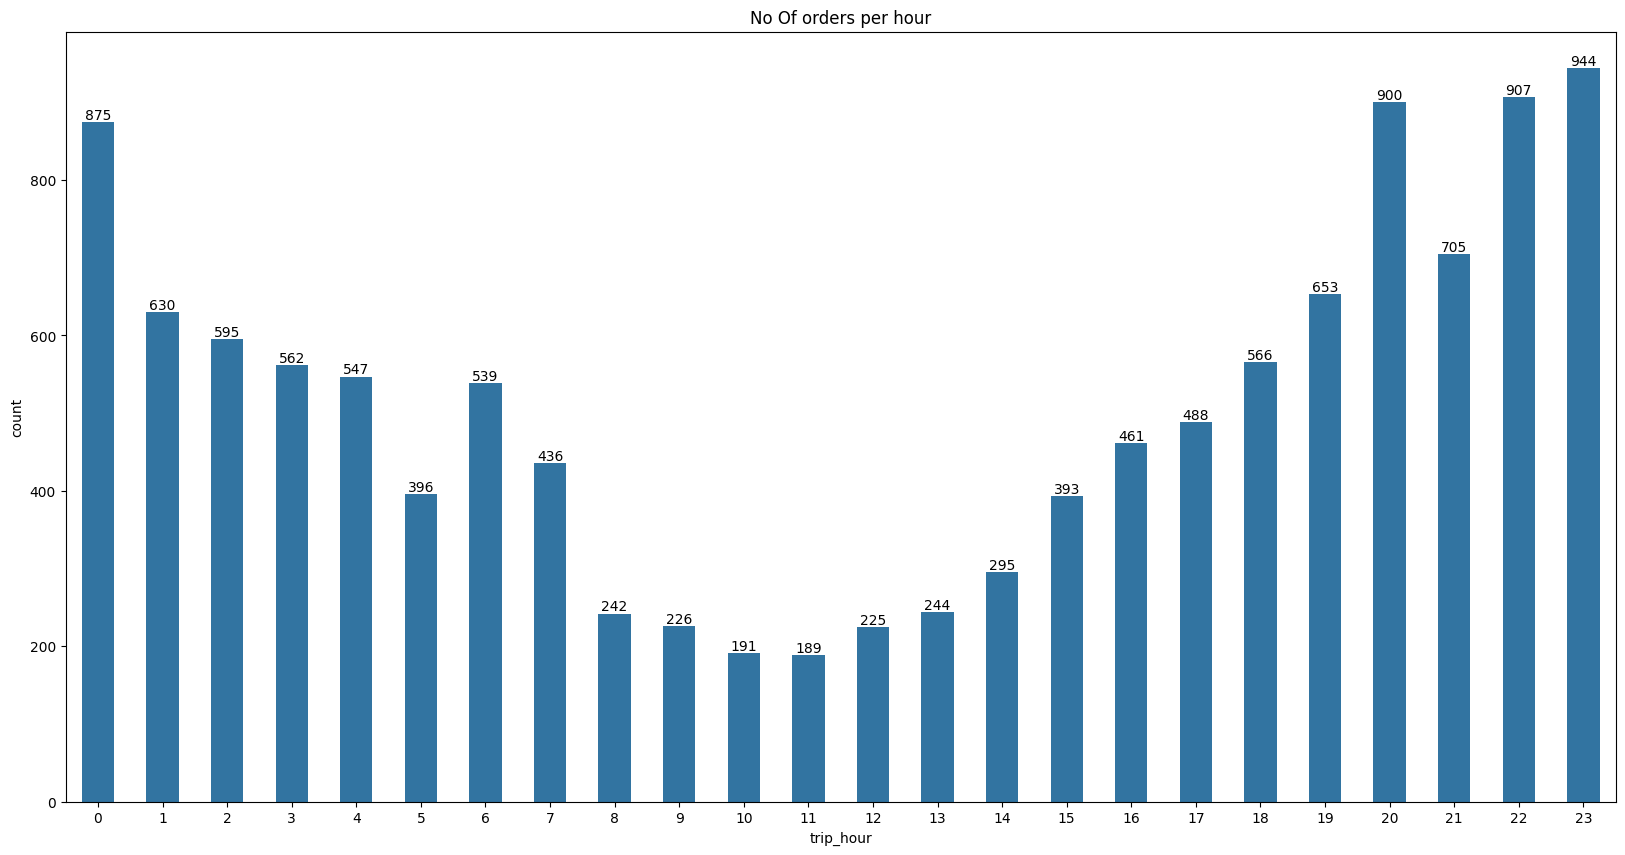

In [202]:
plt.figure(figsize=(20,10))
plt.title('No Of orders per hour')
ax= sns.barplot(data= data['trip_hour'].value_counts().reset_index(), x= 'trip_hour', y= 'count', width=0.5)
ax.bar_label(ax.containers[0])
plt.show()

*>**Insight:** Peak order hours are from 18:00hrs to 04:00hrs*

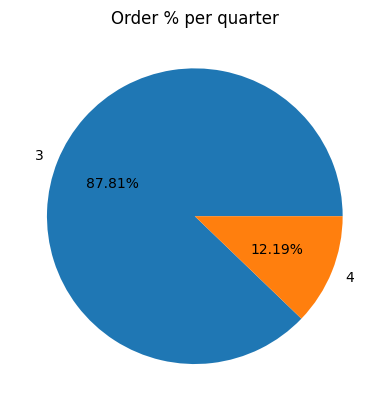

In [203]:
plt.title('Order % per quarter')
value= data['trip_quarter'].value_counts()
type_data= data['trip_quarter'].value_counts().index
plt.pie(value, labels= type_data, autopct= '%2.2f%%')
plt.show()

*>**Insight:** 87.81% of orders were made in Q3 and 12.19% of orders were made in Q4*

**Top 10 Busiest corridor, distance between them, time taken**

In [204]:
data.loc[data['od_time_diff_hour'].sort_values(ascending= False).head(10).index, ['source_city', 'destination_city', 'actual_distance_to_destination', 'od_time_diff_hour']]

,source_city,destination_city,actual_distance_to_destination,od_time_diff_hour
2309,hisar,sidhmukh,118.282024,2059.994797
10957,chomu,jaipur,362.886493,1445.457078
486,sonipat,sonipat,117.929948,1428.207712
3409,akola,akola,115.036743,1391.247158
5608,guwahati,silapathar,204.216582,1373.353693
2703,delhi,delhi,241.495701,1365.264233
9338,bhubaneshwar,kolkata,253.109969,1318.359147
2143,delhi,delhi,242.303877,1288.500923
296,delhi,delhi,240.683625,1241.467158
1502,sonipat,sonipat,241.697491,1236.732531


# **6. Perform One-Hot Encoding or Label encoding On Categorical Features**

**Data Categorical Features**

In [205]:
cat_cols

Index(['data', 'route_type'], dtype='object')

In [206]:
data[cat_cols[0]].value_counts()

,count
data,
training,8732
test,3477


**We will perform Label encoding as it has only 2 categories**

In [207]:
data[cat_cols[0]]= data[cat_cols[0]].map({'training':0, 'test':1})
data[cat_cols[0]].sample(10)

,data
10301,1
6592,0
4650,0
9058,1
8406,0
9319,1
3908,0
3072,0
3937,0
9664,1


**We have performed Label encoding on DATA col and mapped training to 0 and test to 1**

**Route Type Categorical Features**

In [208]:
data[cat_cols[1]].value_counts()

,count
route_type,
Carting,8701
FTL,3508


*We will perform Label encoding as it has only 2 categories*

In [209]:
data[cat_cols[1]]= data[cat_cols[1]].map({'Carting':0, 'FTL':1})
data[cat_cols[1]].sample(10)

,route_type
9697,0
7862,1
1795,0
3277,0
2606,0
5495,0
1279,1
11232,0
4714,1
2831,0


**We have performed Label encoding encoding on DATA col and mapped Carting to 0 and FTL to 1**

**Day Of Week and Month Categorical Features**

*We will perform On-Hot encoding for Month and Day Of week, as the data has more than 2 cat and is NOT Ordinal*

In [210]:
encoded_data= OneHotEncoder(sparse_output= False)
encoded_df= encoded_data.fit_transform(data[['trip_day', 'trip_month']])
encoded_df= pd.DataFrame(encoded_df, columns= encoded_data.get_feature_names_out(['trip_day', 'trip_month']))
encoded_df.columns= encoded_df.columns.str.replace('trip_day_', '')
encoded_df.columns= encoded_df.columns.str.replace('trip_month_', '')
encoded_df.columns= encoded_df.columns.str.replace('trip_', '')
data= pd.concat([data, encoded_df], axis= 1)
data.drop(['trip_day', 'trip_month'], axis= 1, inplace= True)
data.iloc[:,-9:]

,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,October,September
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
12204,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
12205,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
12206,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
12207,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


# **7. Normalize/ Standardize The Numerical Features Using MinMaxScaler or StandardScaler**

In [211]:
data[num_cols].head(5)

,start_scan_to_end_scan,actual_time,osrm_time,segment_actual_time,segment_osrm_time,actual_distance_to_destination,osrm_distance,segment_osrm_distance
0,180.0,143.0,68.0,141.0,65.0,73.186911,85.1110,84.1894
1,100.0,59.0,15.0,59.0,16.0,17.175274,19.6800,19.8766
2,717.0,341.0,117.0,340.0,115.0,127.448500,146.7918,146.7919
3,189.0,61.0,23.0,60.0,23.0,24.597048,28.0647,28.0647
4,98.0,24.0,13.0,24.0,13.0,9.100510,12.0184,12.0184


*Data before Standardization is in different scale*

**Standardization of num cols is done using StandardScaler**

In [212]:
Standard_Scaler= StandardScaler()
data[num_cols]= Standard_Scaler.fit_transform(data[num_cols])

In [213]:
data[num_cols].head(5)

,start_scan_to_end_scan,actual_time,osrm_time,segment_actual_time,segment_osrm_time,actual_distance_to_destination,osrm_distance,segment_osrm_distance
0,-0.524759,-0.145299,-0.080451,-0.149380,-0.210233,0.087566,-0.004474,-0.084047
1,-0.910699,-0.747461,-0.865991,-0.741617,-0.862055,-0.750597,-0.790634,-0.808488
2,2.065866,1.274083,0.645804,1.287879,0.454890,0.899541,0.736627,0.621128
3,-0.481340,-0.733124,-0.747419,-0.734395,-0.768937,-0.639537,-0.689891,-0.716254
4,-0.920348,-0.998362,-0.895634,-0.994401,-0.901962,-0.871428,-0.882689,-0.897005


In [214]:
data[num_cols].describe()

,start_scan_to_end_scan,actual_time,osrm_time,segment_actual_time,segment_osrm_time,actual_distance_to_destination,osrm_distance,segment_osrm_distance
count,1.220900e+04,1.220900e+04,1.220900e+04,1.220900e+04,1.220900e+04,1.220900e+04,1.220900e+04,1.220900e+04
mean,-4.073879e-17,-8.846138e-17,-8.380552e-17,-3.259103e-17,8.380552e-17,-9.311724e-18,-8.380552e-17,1.326921e-16
std,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00
min,-1.282167e+00,-1.105891e+00,-9.845633e-01,-1.102737e+00,-9.817768e-01,-8.728952e-01,-9.180794e-01,-9.301840e-01
25%,-7.514988e-01,-7.402925e-01,-7.029545e-01,-7.416171e-01,-7.157273e-01,-6.915708e-01,-6.933274e-01,-7.064260e-01
50%,-3.173158e-01,-3.961999e-01,-3.917026e-01,-3.949417e-01,-3.964680e-01,-4.601128e-01,-4.766712e-01,-4.472204e-01
75%,4.883349e-01,4.855375e-01,3.938380e-01,4.861916e-01,4.548903e-01,4.067767e-01,4.436505e-01,4.509868e-01
max,3.146500e+00,3.596708e+00,4.588328e+00,3.620715e+00,4.804799e+00,4.877106e+00,4.644009e+00,4.454250e+00


**Num Cols are now Standardized**




# **8. Insights & Recommendations**

**1. Actual Time > OSRM Time:**

*Actual delivery time is significantly higher than the OSRM time.*

**Inaccuracy of OSRM Time Predictions:**
*The substantial difference between actual and OSRM time suggests that the OSRM routing engine does not fully capture real-world delays like traffic conditions, route diversions, or waiting times.*

**Possible Traffic or External Delays:**
*The OSRM model may be failing to account for unforeseen factors such as weather, road closures, or delivery delays at specific points, especially in urban areas.*

**Recommendations:**
*Real-Time Traffic Data Integration: Enhance the OSRM time calculations by integrating real-time traffic data, roadwork schedules, and weather information to make predictions more accurate.*

**Utilize AI for Dynamic Routing:**
*Implement machine learning models to dynamically adjust routes based on live conditions (e.g., accidents, traffic jams, etc.).*

**Incorporate Buffer Time for High-Risk Routes:**
*Identify routes with frequent discrepancies between actual and OSRM time and incorporate buffer time into predictions to account for potential delays.*

**Improve Last-Mile Delivery Optimization:**
*Since last-mile deliveries often cause delays, consider optimizing the delivery strategy for urban areas, perhaps using smaller vehicles or local courier networks to enhance speed.*

**2. Actual Delivery Time > Segment Actual Time:**

*Actual delivery time is statistically greater than segment actual time.*

**Time spent at checkpoints:**
*Loading/unloading delays, waiting at source or destination hubs.*

**Unaccounted waiting time:**
*Delays due to waiting for clearance or permissions at certain facilities.*

**Idle time:**
*Vehicles may be idle due to inefficiencies in the scheduling or route transitions between segments.*

**Traffic or environmental factors not accounted for in segments:**
*While segment times account for distance, they might not fully capture delays from factors like road closures, accidents, or adverse weather conditions.*

**Operational Bottlenecks:**
*There could be bottlenecks in the process where deliveries get delayed between segments, such as at customs, warehouses, or during vehicle changes. These delays may not be reflected in the segment-level data, which focuses on the distance and time between specific origin and destination points.*

**Inefficiencies in Routing or Scheduling:**
*If the actual time is consistently greater than the segment time, it could indicate that there are inefficiencies in the route planning or vehicle scheduling. The vehicles might be spending more time in transit than expected due to poor route optimization or suboptimal schedules.*

**Recommendations:**

**Identify Bottlenecks in the Workflow:**
*Review Checkpoints and Transition Times: Examine the time spent at different checkpoints (e.g., loading docks, customs, transitions between different transport modes) to identify areas where unnecessary delays are occurring.*

**Optimize Handling at Checkpoints:**
*Minimize idle time during loading/unloading or waiting at warehouses. Introduce faster handling processes (e.g., better workforce management, automated systems for sorting goods).*

**Improve Coordination Between Segments:**
*Ensure smoother transitions between segments (e.g., seamless handover between truck and cart, or between different vehicles).*

**Enhance Real-Time Monitoring:**
*Real-Time Tracking: Implement real-time GPS tracking and live traffic updates to monitor delays during transit. By analyzing real-time data, Delhivery can predict and minimize delays during the journey.*

**Dynamic Routing Adjustments:**
*Use real-time data to make dynamic adjustments to routes to avoid traffic jams or road closures, which might not be captured in the segment-level routing model.*

**Optimize Vehicle Scheduling and Resource Allocation:**
 *If there are delays due to scheduling inefficiencies, consider adjusting delivery windows, especially for routes with high delivery volume, to ensure smoother operations.*

**Flexible Delivery Windows:**
*Introduce flexible delivery windows for high-volume corridors, ensuring that Delhivery can manage and account for unexpected delays.*

**Implement Buffer Time for Unaccounted Delays:**
*Buffer Time Integration: For high-risk corridors or areas with frequent delays, build buffer time into the overall delivery time estimate. This allows Delhivery to manage customer expectations and avoid missed deadlines.*

**3. OSRM Distance > Segment OSRM Distance:**

*OSRM distance is significantly greater than the segment OSRM distance.*

**OSRM Distance Overestimates Actual Segment Distances:**
*The OSRM model appears to overestimate the total distance compared to actual segment-level distances, which may be a result of considering factors like detours, road types, or even a route optimization strategy that doesn't fully align with the real-world path.*

**Unaccounted Factors in OSRM Routing:**
*OSRM may include detours or use longer paths in its routing calculations, leading to overestimations of the distance between source and destination.*

**Recommendations:**

**Refine OSRM Path Calculation:**
*Review the algorithms used by OSRM for path calculations and explore the possibility of reducing the overestimation by considering real-world route deviations such as road closures or accidents.*

**Improve Data Integration:**
*Introduce more accurate real-time mapping and routing data into OSRM, perhaps through collaboration with traffic monitoring systems or GPS-based distance tracking.*

**Use Segment-Level Data for Accurate Distance Estimation:**
*Since segment-level distances are more reliable, rely on these when planning or forecasting trip distances to reduce inconsistencies.*

**4. OSRM Time > Segment OSRM Time:**

*OSRM time is significantly greater than segment OSRM time.*

**Overestimation of Time by OSRM:**
*The OSRM time appears to overestimate the total time when compared to segment-wise OSRM time calculations. This could be due to the inclusion of additional time in the model for buffer, potential delays, or other time-related factors like traffic or minor stops.*

**Inconsistent OSRM Time Application:**
*The discrepancy between total OSRM time and segment-level OSRM time suggests that the model’s assumptions at the macro level (whole trip) are different from those at the micro level (individual segments).*

**Recommendations:**

**Segment-Level Time Analysis:**
*Consider using the segment OSRM time as a more reliable predictor for trip time, especially in cases where the total OSRM time is overestimated.*

**Refine OSRM for Time Accuracy:**
*Investigate the OSRM time overestimation by reviewing the time delays included for entire trips, which might be an artifact of overly cautious assumptions in the model.*

**Incorporate Real-Time Feedback for Accurate Predictions:**
*Improve OSRM time predictions by integrating real-time traffic and delivery data to adjust expected times more accurately across different segments.*

**5. Business Insights from Data:**

**Patterns in Order Origins (State, Corridor, etc.):**
*By examining the data for source_state and destination_state, we can identify which regions or corridors generate the highest number of orders. This can help Delhivery optimize its logistics network by focusing on high-demand regions.*

**Top Origin States:** *If we find that specific states (e.g., Maharashtra, Gujarat, Tamil Nadu) are the most frequent sources for trips, it suggests that Delhivery should focus more resources in those regions, like increasing fleet availability or enhancing partnerships with local warehouses.*

**Most Active Corridors:** *Identifying high-frequency corridors (routes between specific source and destination centers) will provide Delhivery with valuable insights into the busiest routes. These corridors could be prioritized for faster service or more frequent trips.*

**Busiest Corridors (Traffic Patterns and Delivery Density):**

**Frequency of Trips:** *By grouping trips by source and destination, we can identify the busiest corridors. For example, if "Mumbai to Pune" is a frequently traveled route, this may indicate a need to increase the capacity of this route, reduce delivery times, or add more vehicles.*

**Average Distance Between Corridors:** *We can calculate the average distance between source and destination for each corridor. This can reveal areas where Delhivery might be able to introduce more efficient routes.*

**Average Time Between Corridors:** *By calculating the average time between source and destination centers, we can identify corridors where Delhivery is experiencing delays or inefficiencies. This data is critical for improving service consistency.*

**Busiest Routes and Locations:** *Geographic Hotspots: Identifying the busiest source and destination locations (cities or regions) will give Delhivery a clearer picture of where most packages are coming from and going to. It could help Delhivery in forecasting demand and preparing resources in advance.*

**Delivery Volume by Location:** *Pinpointing areas with a high number of deliveries could help Delhivery make decisions about whether to open new delivery hubs, expand warehouse capabilities, or introduce new transport strategies for those areas.*

**6. Actionable Business Recommendations:**

*Optimize High-Demand Routes: Based on the most frequent corridors and routes, prioritize those for optimized delivery solutions.*

**Increased Fleet Capacity:** *Add more vehicles or trucks to high-demand routes.*

**Faster Routes:** *If specific corridors have long delivery times, consider revising the routing strategy, such as adding express options for time-sensitive deliveries.*

**Local Partnerships:** *Form partnerships with local transport providers to handle the surge in deliveries for specific regions.*

**Refine Last-Mile Delivery for High-Density Locations:** *In locations with high delivery volumes (e.g., metropolitan cities or industrial hubs)*

**Local Distribution Centers:** *Set up smaller local warehouses or hubs to handle the last-mile delivery more efficiently.*

**Crowdsourced Delivery Options:** *For urban areas, integrating crowdsourced delivery options (e.g., local delivery agents or small vehicles) can reduce congestion and improve delivery speed.*

**Collaborate with Local Couriers:** *Work with local couriers for last-mile delivery, especially in high-density areas, to improve service levels and cut costs.*

**Leverage Real-Time Data for Dynamic Routing:** *Integrate real-time traffic data into the routing engine to adjust routes on the fly, reducing delays and improving on-time delivery rates. This can be particularly useful for busy corridors with unpredictable traffic.*

**Predictive Analytics for Peak Hours:** *Use historical data to predict peak traffic times for certain routes. This allows Delhivery to plan accordingly and optimize delivery times during rush hours.*

**Improve Inventory and Resource Allocation:**  *Based on the busiest routes and corridors, Delhivery can forecast demand and plan fleet resources in advance. This also helps in anticipating and mitigating any potential delivery delays.*

**Better Capacity Planning:** *Align the number of vehicles, warehouses, and delivery agents with the expected volume of deliveries from high-demand areas. This will improve efficiency and help Delhivery stay ahead during busy periods.*

**Focus on Efficiency in Long-Distance Routes:** *For corridors with longer average distances between source and destination*

**Specialized Long-Distance Vehicles:** *Use larger trucks or optimized vehicles for long-distance routes to reduce fuel costs and improve delivery speed.*

**Cross-Docking:** *Use cross-docking techniques in major transit hubs to transfer goods between different vehicles, reducing transit times and improving delivery efficiency.*

**Enhanced Customer Experience Through Predictive Delivery Times:** *Use historical data to predict delivery times more accurately, setting realistic customer expectations and providing better service.*

**Proactive Notifications:** *Notify customers about expected delivery times and potential delays, enhancing transparency and trust in the service.*

**Continuous Monitoring and Feedback Loop:** *Customer Feedback Integration: Collect feedback on delivery times, delays, and customer satisfaction to identify specific pain points in the logistics chain.*

**Continuous Improvement:** *Regularly monitor key metrics like on-time delivery rate, delivery speed, and customer satisfaction to continuously refine routes, capacity planning, and resource allocation.*

# **THANK YOU**

# **-Delhivery Case Study By: Nitish Vishwanath Hatapaki**